# Double-Zernike Decomposition: Finding Astigmatic Field Patterns

**Author:** Aaron Roodman  
**Date Created:** 2026-03-18  
**Last Modified:** 2026-03-18  
**Status:** In Progress  
**Keywords:** AOS, sensitivity matrix, double Zernike, astigmatism, field dependence  

## Description

This notebook finds which telescope degrees of freedom (DOFs) produce wavefront patterns
described by specific **double-Zernike** terms. The double-Zernike basis uses one Zernike
polynomial (index j, Noll convention) for the pupil-plane wavefront and another (index k)
for the variation of that wavefront across the focal plane.

**Primary goal:** Identify DOF(s) that produce **(j=5, k=5)** or **(j=6, k=6)** patterns —
astigmatism in the pupil whose amplitude varies as astigmatism across the field.

Key functionality:
1. Evaluate the sensitivity matrix at the 4 WFS corners **plus extra field points** to
   break the rank degeneracy that arises with only 4 positions
2. Project each column of the sensitivity matrix onto the double-Zernike basis (k=1–6)
3. Rank DOFs by their (j=5,k=5) and (j=6,k=6) content
4. Visualize and verify the wavefront patterns of the best-matching DOFs

**Output:** Plots and tables identifying which DOFs produce astigmatic field patterns.

**Based on:** `smatrix_vmode_info.ipynb` Section 10, `aos control equations.docx`

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-03-18 | Aaron Roodman | Initial version |
| 2026-03-18 | Aaron Roodman | Added extra field points to break rank degeneracy |
| 2026-03-18 | Aaron Roodman | Added diagonal field points for Z5 resolution; RSP auto-detection; clarified figures |
| 2026-03-24 | Aaron Roodman | Added physical units, expanded verification docs, physical impact section |
| 2026-03-24 | Aaron Roodman | Added (j=4,k=4) defocus target DZ term; linear-scale DZ heatmap |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Load Sensitivity Matrix](#load)
4. [Extended Focal-Plane Zernike Basis](#fp-zernike)
5. [Build Double-Zernike Basis Vectors](#dz-basis)
6. [Project Sensitivity Matrix onto DZ Basis](#projection)
7. [DOF Wavefront Pattern Verification](#verification)
8. [Physical Impact at Field Points](#physical-impact)
9. [Summary](#summary)

<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters
# ============================================================

# OFC configuration directory — auto-detected from RSP location
# Override manually if running locally or in a non-standard environment.
# Uses detect_rsp_location() and get_packages_dir() from common.utils
# (imported in the next cell).
# Summit: /home/aroodman/packages/ts_config_mttcs/MTAOS/v8/ofc
# USDF:   /home/r/roodman/u/LSST/packages/ts_config_mttcs/MTAOS/v8/ofc
ofc_config_subpath = 'ts_config_mttcs/MTAOS/v8/ofc'

# --- DOF labels (all 50) ---
labels_50dof = [
    'M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry',
    'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry',
    'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5',
    'B1_6', 'B1_7', 'B1_8', 'B1_9', 'B1_10',
    'B1_11', 'B1_12', 'B1_13', 'B1_14', 'B1_15',
    'B1_16', 'B1_17', 'B1_18', 'B1_19', 'B1_20',
    'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5',
    'B2_6', 'B2_7', 'B2_8', 'B2_9', 'B2_10',
    'B2_11', 'B2_12', 'B2_13', 'B2_14', 'B2_15',
    'B2_16', 'B2_17', 'B2_18', 'B2_19', 'B2_20',
]

# --- Physical units for each DOF ---
# M2/Cam translations (dz, dx, dy): microns
# M2/Cam rotations (rx, ry): arcsec
# Bending modes (B1_*, B2_*): microns
dof_units_50 = (
    ['μm'] * 3 + ['arcsec'] * 2 +    # M2: dz, dx, dy, rx, ry
    ['μm'] * 3 + ['arcsec'] * 2 +    # Cam: dz, dx, dy, rx, ry
    ['μm'] * 20 +                     # B1 bending modes
    ['μm'] * 20                       # B2 bending modes
)

# --- Zernike selection (pupil-plane, Noll indices) ---
# Same selection as smatrix_vmode_info
zn = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]

# --- WFS corners (used for the standard AOS measurement) ---
sensor_name_list = ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0']

# --- Extra field points (degrees) to supplement the 4 WFS corners ---
# These break the rank degeneracy when fitting focal-plane Zernikes k=1-6.
# With 4 corner WFS alone, Z1-Z6 span only a 4D subspace of R^4.
#
# IMPORTANT: Points on the cardinal axes (0, 90, 180, 270 deg) have sin(2*theta)=0,
# so they provide ZERO information for the k=5 (astig-45) focal-plane Zernike.
# Diagonal points at 45/135/225/315 deg are needed to resolve k=5.
extra_field_points = [
    (0.0, 0.0),       # ExtraCtr  — field center
    (0.5, 0.0),       # Extra0    — 0 deg on focal plane
    (0.0, 0.5),       # Extra90   — 90 deg
    (-0.5, 0.0),      # Extra180  — 180 deg
    (0.0, -0.5),      # Extra270  — 270 deg
    (0.35, 0.35),     # Extra45   — 45 deg (sin(2*theta)=+1, Z5 maximal)
    (-0.35, 0.35),    # Extra135  — 135 deg (sin(2*theta)=-1)
    (-0.35, -0.35),   # Extra225  — 225 deg (sin(2*theta)=+1)
    (0.35, -0.35),    # Extra315  — 315 deg (sin(2*theta)=-1)
]

# Descriptive names for extra field points (angle on focal plane)
extra_field_labels = [
    'ExtraCtr', 'Extra0', 'Extra90', 'Extra180', 'Extra270',
    'Extra45', 'Extra135', 'Extra225', 'Extra315',
]

# --- Target double-Zernike terms ---
# (j, k) where j = pupil Zernike, k = focal-plane Zernike
target_dz_terms = [(5, 5), (6, 6), (5, 6), (6, 5), (4, 4)]

# --- Max focal-plane Zernike order to evaluate ---
k_fp_max = 6

# --- Pupil Zernike range for DZ decomposition ---
j_min, j_max = 4, 11  # Noll indices

<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import colors, cm
from lsst.ts.ofc import OFC, OFCData, SensitivityMatrix

# Add repo root to sys.path for common imports
sys.path.insert(0, str(Path.cwd().parent))
from common.utils import detect_rsp_location, get_packages_dir

%matplotlib inline

zn = np.array(zn)
zn_idx = zn - 4
n_zernike = len(zn)
n_wfs = len(sensor_name_list)
n_extra = len(extra_field_points)
n_fp = n_wfs + n_extra  # total field positions for DZ fitting

print(f'Pupil Zernike terms: {zn} ({n_zernike} terms)')
print(f'WFS sensors: {sensor_name_list} ({n_wfs} sensors)')
print(f'Extra field points: {n_extra}')
print(f'Total field positions for DZ fitting: {n_fp}')
print(f'Measurement vector length (per field point): {n_zernike}')

Pupil Zernike terms: [ 4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 22 23 24 25 26] (21 terms)
WFS sensors: ['R00_SW0', 'R04_SW0', 'R40_SW0', 'R44_SW0'] (4 sensors)
Extra field points: 9
Total field positions for DZ fitting: 13
Measurement vector length (per field point): 21


<a id='load'></a>
## 3. Load Sensitivity Matrix

We evaluate the sensitivity matrix at **all field positions**: the 4 WFS corners
plus the extra field points. `SensitivityMatrix.evaluate()` accepts arbitrary
field angles, so we pass all 9 positions in a single call.

In [3]:
# Auto-detect RSP location and set ofc_config_dir
rsp_location = detect_rsp_location()
print(f'Detected RSP location: {rsp_location}')

if rsp_location == 'local':
    # Fallback: set manually if running locally
    ofc_config_dir = '/home/aroodman/packages/' + ofc_config_subpath
    print(f'WARNING: Running locally — using hardcoded Summit path: {ofc_config_dir}')
else:
    ofc_config_dir = get_packages_dir(rsp_location) + '/' + ofc_config_subpath
    print(f'OFC config dir: {ofc_config_dir}')

# Load OFC data
ofc_data = OFCData('lsst', config_dir=ofc_config_dir)

# WFS field angles from the OFC data
wfs_field_angles = [ofc_data.sample_points[sensor] for sensor in sensor_name_list]

# Combined field positions: 4 WFS corners + extra points
all_field_angles = wfs_field_angles + [list(pt) for pt in extra_field_points]

# Labels for all field positions: WFS names + angle-based extra names
fp_labels = [f'WFS{i} ({sensor_name_list[i]})' for i in range(n_wfs)]
fp_labels += extra_field_labels

print(f'\nAll {n_fp} field positions (deg):')
for i, (angle, label) in enumerate(zip(all_field_angles, fp_labels)):
    print(f'  [{i:2d}] {label:15s}: ({angle[0]:7.4f}, {angle[1]:7.4f})')

Detected RSP location: usdf
OFC config dir: /home/r/roodman/u/LSST/packages/ts_config_mttcs/MTAOS/v8/ofc

All 13 field positions (deg):
  [ 0] WFS0 (R00_SW0) : (-1.1903, -1.1903)
  [ 1] WFS1 (R04_SW0) : (-1.1903,  1.1903)
  [ 2] WFS2 (R40_SW0) : ( 1.1903, -1.1903)
  [ 3] WFS3 (R44_SW0) : ( 1.1903,  1.1903)
  [ 4] ExtraCtr       : ( 0.0000,  0.0000)
  [ 5] Extra0         : ( 0.5000,  0.0000)
  [ 6] Extra90        : ( 0.0000,  0.5000)
  [ 7] Extra180       : (-0.5000,  0.0000)
  [ 8] Extra270       : ( 0.0000, -0.5000)
  [ 9] Extra45        : ( 0.3500,  0.3500)
  [10] Extra135       : (-0.3500,  0.3500)
  [11] Extra225       : (-0.3500, -0.3500)
  [12] Extra315       : ( 0.3500, -0.3500)


In [4]:
# Evaluate sensitivity matrix at ALL field positions
dz_sensitivity_matrix = SensitivityMatrix(ofc_data)
sens_3d = dz_sensitivity_matrix.evaluate(all_field_angles, 0.0)
print(f'Raw 3D sensitivity matrix shape: {sens_3d.shape}  (n_fp, n_zernike_full, n_dof_full)')

# Select Zernike subset: shape becomes (n_fp, n_zernike, n_dof_full)
sens_3d = sens_3d[:, zn_idx, :]
print(f'After Zernike selection: {sens_3d.shape}  (n_fp, n_zernike, n_dof_full)')

# A_3d[s, p, d] = wavefront change in pupil Zernike p at field position s for DOF d
A_3d = sens_3d  # keep the 3D form for the DZ decomposition
n_dof = A_3d.shape[2]
print(f'Number of DOFs: {n_dof}')

# Also build the flattened 2D form for the WFS-only subset (for verification plots)
A_wfs_2d = sens_3d[:n_wfs, :, :].reshape((-1, n_dof))
print(f'WFS-only 2D sensitivity matrix shape: {A_wfs_2d.shape}  (n_wfs*n_zernike, n_dof)')

# Active DOFs
active_dof_idx = ofc_data.dof_idx
labels_active = [labels_50dof[i] for i in active_dof_idx]
print(f'Active DOFs ({len(active_dof_idx)}): {labels_active}')

Raw 3D sensitivity matrix shape: (13, 25, 50)  (n_fp, n_zernike_full, n_dof_full)
After Zernike selection: (13, 21, 50)  (n_fp, n_zernike, n_dof_full)
Number of DOFs: 50
WFS-only 2D sensitivity matrix shape: (84, 50)  (n_wfs*n_zernike, n_dof)
Active DOFs (50): ['M2_dz', 'M2_dx', 'M2_dy', 'M2_rx', 'M2_ry', 'Cam_dz', 'Cam_dx', 'Cam_dy', 'Cam_rx', 'Cam_ry', 'B1_1', 'B1_2', 'B1_3', 'B1_4', 'B1_5', 'B1_6', 'B1_7', 'B1_8', 'B1_9', 'B1_10', 'B1_11', 'B1_12', 'B1_13', 'B1_14', 'B1_15', 'B1_16', 'B1_17', 'B1_18', 'B1_19', 'B1_20', 'B2_1', 'B2_2', 'B2_3', 'B2_4', 'B2_5', 'B2_6', 'B2_7', 'B2_8', 'B2_9', 'B2_10', 'B2_11', 'B2_12', 'B2_13', 'B2_14', 'B2_15', 'B2_16', 'B2_17', 'B2_18', 'B2_19', 'B2_20']


<a id='fp-zernike'></a>
## 4. Extended Focal-Plane Zernike Basis

We evaluate Noll Zernike polynomials Z1–Z6 at all 9 field positions. With 9 points,
the 6 focal-plane Zernike vectors live in R^9 and should be **full rank** (rank 6),
breaking the degeneracy that existed with only 4 WFS corners.

Noll Zernike polynomials (on the unit circle):
- Z1 = 1 (piston)
- Z2 = 2ρ cos(θ) (x-tilt)
- Z3 = 2ρ sin(θ) (y-tilt)
- Z4 = √3(2ρ² − 1) (defocus)
- Z5 = √6 ρ² sin(2θ) (astigmatism-45)
- Z6 = √6 ρ² cos(2θ) (astigmatism-0)

In [5]:
# All field positions as an array
fp_xy = np.array(all_field_angles)  # shape (n_fp, 2)

# Normalize to unit circle using the maximum radius across ALL positions
R_fp = np.max(np.sqrt(fp_xy[:, 0]**2 + fp_xy[:, 1]**2))
x_norm = fp_xy[:, 0] / R_fp
y_norm = fp_xy[:, 1] / R_fp
rho = np.sqrt(x_norm**2 + y_norm**2)
theta = np.arctan2(y_norm, x_norm)

print(f'Normalization radius R_fp = {R_fp:.4f} deg')
print(f'\nNormalized field positions:')
for i in range(n_fp):
    print(f'  [{i:2d}] {fp_labels[i]:30s}  x={x_norm[i]:7.4f}, y={y_norm[i]:7.4f}, '
          f'rho={rho[i]:.4f}, theta={np.degrees(theta[i]):7.1f} deg')

Normalization radius R_fp = 1.6833 deg

Normalized field positions:
  [ 0] WFS0 (R00_SW0)                  x=-0.7071, y=-0.7071, rho=1.0000, theta= -135.0 deg
  [ 1] WFS1 (R04_SW0)                  x=-0.7071, y= 0.7071, rho=1.0000, theta=  135.0 deg
  [ 2] WFS2 (R40_SW0)                  x= 0.7071, y=-0.7071, rho=1.0000, theta=  -45.0 deg
  [ 3] WFS3 (R44_SW0)                  x= 0.7071, y= 0.7071, rho=1.0000, theta=   45.0 deg
  [ 4] ExtraCtr                        x= 0.0000, y= 0.0000, rho=0.0000, theta=    0.0 deg
  [ 5] Extra0                          x= 0.2970, y= 0.0000, rho=0.2970, theta=    0.0 deg
  [ 6] Extra90                         x= 0.0000, y= 0.2970, rho=0.2970, theta=   90.0 deg
  [ 7] Extra180                        x=-0.2970, y= 0.0000, rho=0.2970, theta=  180.0 deg
  [ 8] Extra270                        x= 0.0000, y=-0.2970, rho=0.2970, theta=  -90.0 deg
  [ 9] Extra45                         x= 0.2079, y= 0.2079, rho=0.2940, theta=   45.0 deg
  [10] Extra135       

In [6]:
# Evaluate Noll Zernike polynomials Z1-Z6 at all field positions
def noll_zernike_at_points(k_noll, rho, theta):
    """Evaluate Noll Zernike polynomial Z_k at given (rho, theta) points."""
    if k_noll == 1:
        return np.ones_like(rho)
    elif k_noll == 2:
        return 2.0 * rho * np.cos(theta)
    elif k_noll == 3:
        return 2.0 * rho * np.sin(theta)
    elif k_noll == 4:
        return np.sqrt(3.0) * (2.0 * rho**2 - 1.0)
    elif k_noll == 5:
        return np.sqrt(6.0) * rho**2 * np.sin(2.0 * theta)
    elif k_noll == 6:
        return np.sqrt(6.0) * rho**2 * np.cos(2.0 * theta)
    else:
        raise ValueError(f'Noll index {k_noll} not implemented (only 1-6)')

fp_zernike_names = {1: 'piston', 2: 'x-tilt', 3: 'y-tilt',
                     4: 'defocus', 5: 'astig-45', 6: 'astig-0'}

# Build fp Zernike values: fp_zernike_vals[k] is length n_fp
fp_zernike_vals = {}
print(f'Focal-plane Zernike values at {n_fp} field positions:')
header = f'{"k":>3s} {"name":>10s}  ' + '  '.join([f'[{i}]' for i in range(n_fp)])
print(header)
print('-' * len(header))
for k in range(1, k_fp_max + 1):
    vals = noll_zernike_at_points(k, rho, theta)
    fp_zernike_vals[k] = vals
    val_str = '  '.join([f'{v:5.2f}' for v in vals])
    print(f'{k:3d} {fp_zernike_names[k]:>10s}  {val_str}')

Focal-plane Zernike values at 13 field positions:
  k       name  [0]  [1]  [2]  [3]  [4]  [5]  [6]  [7]  [8]  [9]  [10]  [11]  [12]
----------------------------------------------------------------------------------
  1     piston   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00   1.00
  2     x-tilt  -1.41  -1.41   1.41   1.41   0.00   0.59   0.00  -0.59   0.00   0.42  -0.42  -0.42   0.42
  3     y-tilt  -1.41   1.41  -1.41   1.41   0.00   0.00   0.59   0.00  -0.59   0.42   0.42  -0.42  -0.42
  4    defocus   1.73   1.73   1.73   1.73  -1.73  -1.43  -1.43  -1.43  -1.43  -1.43  -1.43  -1.43  -1.43
  5   astig-45   2.45  -2.45  -2.45   2.45   0.00   0.00   0.00  -0.00  -0.00   0.21  -0.21   0.21  -0.21
  6    astig-0  -0.00  -0.00   0.00   0.00   0.00   0.22  -0.22   0.22  -0.22   0.00  -0.00  -0.00   0.00


In [7]:
# Check rank of the focal-plane Zernike design matrix
FP = np.column_stack([fp_zernike_vals[k] for k in range(1, k_fp_max + 1)])  # (n_fp, 6)
gram = FP.T @ FP  # (6, 6)

print(f'Focal-plane Zernike design matrix shape: {FP.shape} (n_fp x k_fp_max)')
print(f'\nGram matrix (FP^T @ FP):')
print(f'{"":>8s}  ' + '  '.join([f'Z{i+1:d}' for i in range(k_fp_max)]))
for i in range(k_fp_max):
    row_str = '  '.join([f'{gram[i, j]:8.4f}' for j in range(k_fp_max)])
    print(f'  Z{i+1}: {row_str}')

U_fp, s_fp, Vh_fp = np.linalg.svd(FP, full_matrices=False)
print(f'\nSingular values of FP design matrix: {np.array2string(s_fp, precision=4)}')
rank = np.sum(s_fp > 1e-10)
print(f'Rank: {rank}')
print(f'Condition number: {s_fp[0] / s_fp[rank-1]:.2f}')

if rank >= k_fp_max:
    print(f'\nZ1-Z{k_fp_max} are FULLY RESOLVABLE with {n_fp} field positions.')
else:
    print(f'\nWARNING: Only {rank} of {k_fp_max} focal-plane Zernikes are resolvable.')
    print('Consider adding more field points or reducing k_fp_max.')

Focal-plane Zernike design matrix shape: (13, 6) (n_fp x k_fp_max)

Gram matrix (FP^T @ FP):
          Z1  Z2  Z3  Z4  Z5  Z6
  Z1:  13.0000    0.0000    0.0000   -6.2396   -0.0000   -0.0000
  Z2:   0.0000    9.3976   -0.0000    0.0000    0.0000    0.0000
  Z3:   0.0000   -0.0000    9.3976   -0.0000   -0.0000    0.0000
  Z4:  -6.2396    0.0000   -0.0000   31.3472    0.0000   -0.0000
  Z5:  -0.0000    0.0000   -0.0000    0.0000   24.1794   -0.0000
  Z6:  -0.0000    0.0000    0.0000   -0.0000   -0.0000    0.1868

Singular values of FP design matrix: [5.7678 4.9173 3.3285 3.0655 3.0655 0.4322]
Rank: 6
Condition number: 13.34

Z1-Z6 are FULLY RESOLVABLE with 13 field positions.


### Focal-Plane Zernike Patterns

The figures below show the **focal-plane Zernike polynomial value** (dimensionless) evaluated
at each field position's normalized (ρ, θ) coordinates. The color at each point represents
the value of the Zernike polynomial Z_k at that field position — this is the expected
spatial pattern of amplitude variation across the focal plane for each mode.

For example, in the Z5 (astig-45) panel, the color shows where on the focal plane the
amplitude of pupil Z5 would be positive (red), negative (blue), or zero (white) for a
DOF that has pure k=5 field dependence.

Two focused figures follow for the **pupil Z5** and **pupil Z6** astigmatism patterns,
comparing the expected focal-plane Zernike pattern to the actual sensitivity of the
top-ranked DOFs.

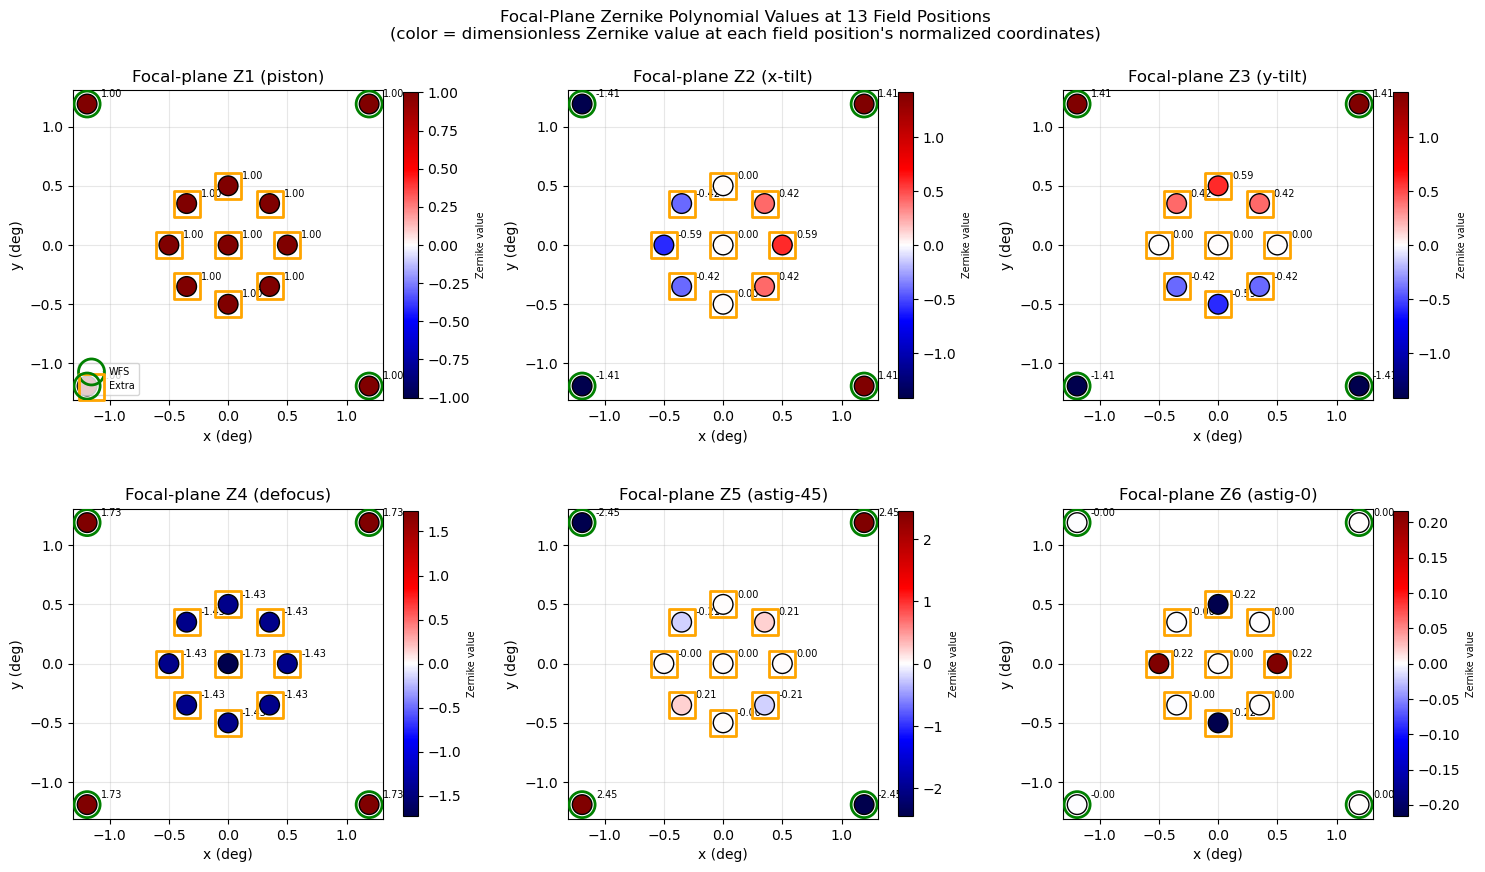

In [8]:
# Visualize the field point layout and focal-plane Zernike patterns
# Color = focal-plane Zernike polynomial value (dimensionless) at each field position
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for idx, (k, ax) in enumerate(zip(range(1, k_fp_max + 1), axes.flat)):
    vals = fp_zernike_vals[k]
    vmax = max(np.max(np.abs(vals)), 0.01)
    scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=vals, cmap='seismic',
                         vmin=-vmax, vmax=vmax, s=200, edgecolors='k', zorder=5)
    for i in range(n_fp):
        ax.annotate(f'{vals[i]:.2f}', (fp_xy[i, 0], fp_xy[i, 1]),
                    textcoords='offset points', xytext=(10, 5), fontsize=7)
    # Mark WFS vs extra
    ax.scatter(fp_xy[:n_wfs, 0], fp_xy[:n_wfs, 1], facecolors='none',
               edgecolors='green', s=350, lw=2, label='WFS', zorder=6)
    ax.scatter(fp_xy[n_wfs:, 0], fp_xy[n_wfs:, 1], facecolors='none',
               edgecolors='orange', s=350, lw=2, marker='s', label='Extra', zorder=6)
    ax.set_xlabel('x (deg)')
    ax.set_ylabel('y (deg)')
    ax.set_title(f'Focal-plane Z{k} ({fp_zernike_names[k]})')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
    cb.set_label('Zernike value', fontsize=7)
    if idx == 0:
        ax.legend(fontsize=7, loc='lower left', bbox_to_anchor=(0.0, 0.0))

fig.suptitle(f'Focal-Plane Zernike Polynomial Values at {n_fp} Field Positions\n'
             f'(color = dimensionless Zernike value at each field position\'s normalized coordinates)',
             fontsize=12)
fig.tight_layout()
plt.show()

<a id='dz-basis'></a>
## 5. Build Double-Zernike Basis Vectors

A double-Zernike term (j, k) represents pupil Zernike Z_j whose amplitude varies as
focal-plane Zernike Z_k across the field.

The measurement vector now has `n_fp` field positions (not just the 4 WFS).
Layout: `index = field_idx * n_zernike + zern_local_idx`

So `dz_vector(j, k)[s * n_zernike + p] = delta(zn[p], j) * Z_k(field_s)`

In [9]:
def make_dz_vector(j_noll, k_fp, zn_array, fp_zernike_dict, n_fp, n_zernike):
    """Create a double-Zernike basis vector for all field positions."""
    vec = np.zeros(n_fp * n_zernike)
    match = np.where(zn_array == j_noll)[0]
    if len(match) == 0:
        return None
    p = match[0]
    fp_vals = fp_zernike_dict[k_fp]
    for s in range(n_fp):
        vec[s * n_zernike + p] = fp_vals[s]
    return vec

# Build all (j, k) double-Zernike basis vectors
dz_terms = []
dz_vectors = {}

for j in range(j_min, j_max + 1):
    for k in range(1, k_fp_max + 1):
        vec = make_dz_vector(j, k, zn, fp_zernike_vals, n_fp, n_zernike)
        if vec is not None:
            dz_terms.append((j, k))
            dz_vectors[(j, k)] = vec

n_dz = len(dz_terms)
print(f'Built {n_dz} double-Zernike basis vectors')
print(f'  j range: {j_min}-{j_max}, k range: 1-{k_fp_max}')
print(f'  Each vector has length {n_fp} x {n_zernike} = {n_fp * n_zernike}')
print(f'\nTarget terms of interest:')
for j, k in target_dz_terms:
    present = (j, k) in dz_vectors
    print(f'  (j={j}, k={k}) = pupil Z{j} x field Z{k} ({fp_zernike_names[k]}): '
          f'{"PRESENT" if present else "MISSING"}')

Built 48 double-Zernike basis vectors
  j range: 4-11, k range: 1-6
  Each vector has length 13 x 21 = 273

Target terms of interest:
  (j=5, k=5) = pupil Z5 x field Z5 (astig-45): PRESENT
  (j=6, k=6) = pupil Z6 x field Z6 (astig-0): PRESENT
  (j=5, k=6) = pupil Z5 x field Z6 (astig-0): PRESENT
  (j=6, k=5) = pupil Z6 x field Z5 (astig-45): PRESENT


In [10]:
# Check orthogonality of DZ basis vectors at all field positions
# With 9 points, the fp Zernike vectors should be much closer to orthogonal.

j_check = 5
k_list = [k for k in range(1, k_fp_max + 1) if (j_check, k) in dz_vectors]
print(f'Overlap matrix for j={j_check} DZ vectors ({n_fp} field positions):')
print(f'{"":>8s}', '  '.join([f'k={k:d}' for k in k_list]))
for ki in k_list:
    vi = dz_vectors[(j_check, ki)]
    row = [np.dot(vi, dz_vectors[(j_check, kj)]) for kj in k_list]
    row_str = '  '.join([f'{v:7.3f}' for v in row])
    print(f'  k={ki:d}:  {row_str}')

# Also show the fp-only overlap (just the Z_k vectors at 9 points)
print(f'\nFocal-plane Zernike overlap matrix (Z_k . Z_l at {n_fp} positions):')
print(f'{"":>8s}', '  '.join([f'Z{k:d}' for k in range(1, k_fp_max + 1)]))
for ki in range(1, k_fp_max + 1):
    row = [np.dot(fp_zernike_vals[ki], fp_zernike_vals[kj])
           for kj in range(1, k_fp_max + 1)]
    row_str = '  '.join([f'{v:7.3f}' for v in row])
    print(f'  Z{ki:d}:  {row_str}')

Overlap matrix for j=5 DZ vectors (13 field positions):
         k=1  k=2  k=3  k=4  k=5  k=6
  k=1:   13.000    0.000    0.000   -6.240    0.000   -0.000
  k=2:    0.000    9.398    0.000    0.000    0.000    0.000
  k=3:    0.000    0.000    9.398   -0.000   -0.000    0.000
  k=4:   -6.240    0.000   -0.000   31.347   -0.000   -0.000
  k=5:    0.000    0.000   -0.000   -0.000   24.179   -0.000
  k=6:   -0.000    0.000    0.000   -0.000   -0.000    0.187

Focal-plane Zernike overlap matrix (Z_k . Z_l at 13 positions):
         Z1  Z2  Z3  Z4  Z5  Z6
  Z1:   13.000    0.000    0.000   -6.240   -0.000   -0.000
  Z2:    0.000    9.398   -0.000    0.000    0.000    0.000
  Z3:    0.000   -0.000    9.398   -0.000   -0.000    0.000
  Z4:   -6.240    0.000   -0.000   31.347    0.000   -0.000
  Z5:   -0.000    0.000   -0.000    0.000   24.179   -0.000
  Z6:   -0.000    0.000    0.000   -0.000   -0.000    0.187


<a id='projection'></a>
## 6. Project Sensitivity Matrix onto Double-Zernike Basis

For each DOF (column of the sensitivity matrix), we decompose its wavefront signature
into double-Zernike coefficients. The sensitivity matrix `A_3d[s, p, d]` gives the
Zernike-p coefficient at field position s for DOF d.

For each pupil Zernike j, the DOF's signature across the field is an n_fp-element
vector. We fit this as a linear combination of the focal-plane Zernike values
Z_k(field_positions) using least-squares.

With 9 field positions and 6 focal-plane Zernikes, the system is overdetermined
(9 equations, 6 unknowns), giving a proper least-squares fit with residuals that
indicate how well the double-Zernike basis captures the actual field variation.

In [11]:
# Focal-plane Zernike design matrix: shape (n_fp, k_fp_max)
FP_design = np.column_stack([fp_zernike_vals[k] for k in range(1, k_fp_max + 1)])
print(f'Focal-plane design matrix shape: {FP_design.shape}  (n_fp x k_fp_max)')
print(f'  This is an OVERDETERMINED system ({n_fp} points, {k_fp_max} parameters)')
print(f'  Least-squares will give best-fit DZ coefficients + residuals')

# Double-Zernike decomposition for ALL 50 DOFs
# A_3d[s, p, d] = sensitivity at field position s, pupil Zernike p, DOF d
n_j = j_max - j_min + 1
n_k = k_fp_max
dz_coeff_all = np.zeros((n_dof, n_j, n_k))
dz_residual_all = np.zeros((n_dof, n_j))  # residual norm for each (DOF, j)

for d in range(n_dof):
    for j_local, j_noll in enumerate(range(j_min, j_max + 1)):
        match = np.where(zn == j_noll)[0]
        if len(match) == 0:
            continue
        p = match[0]
        
        # Extract the n_fp-element vector: A_j values at all field positions for this DOF
        a_j_field = A_3d[:, p, d]  # shape (n_fp,)
        
        # Least-squares fit: a_j_field = FP_design @ c
        c, residuals, rank, sv = np.linalg.lstsq(FP_design, a_j_field, rcond=None)
        dz_coeff_all[d, j_local, :] = c
        
        # Compute residual norm
        fit = FP_design @ c
        dz_residual_all[d, j_local] = np.linalg.norm(a_j_field - fit)

print(f'\nDouble-Zernike coefficient array shape: {dz_coeff_all.shape} (n_dof, n_j, n_k)')
print(f'  j indices (pupil): {list(range(j_min, j_max+1))}')
print(f'  k indices (field): {list(range(1, k_fp_max+1))}')
print(f'\nResidual statistics (how well DZ basis captures field variation):')
print(f'  Max residual norm: {np.max(dz_residual_all):.6f}')
print(f'  Mean residual norm: {np.mean(dz_residual_all):.6f}')
print(f'  Fraction with residual < 1e-6: '
      f'{np.mean(dz_residual_all < 1e-6):.1%}')

Focal-plane design matrix shape: (13, 6)  (n_fp x k_fp_max)
  This is an OVERDETERMINED system (13 points, 6 parameters)
  Least-squares will give best-fit DZ coefficients + residuals

Double-Zernike coefficient array shape: (50, 8, 6) (n_dof, n_j, n_k)
  j indices (pupil): [4, 5, 6, 7, 8, 9, 10, 11]
  k indices (field): [1, 2, 3, 4, 5, 6]

Residual statistics (how well DZ basis captures field variation):
  Max residual norm: 0.757360
  Mean residual norm: 0.029567
  Fraction with residual < 1e-6: 7.8%


In [12]:
# --- Find DOFs with largest (j=5,k=5) and (j=6,k=6) coefficients ---
print('=' * 90)
print('DOFs ranked by target double-Zernike coefficients')
print('=' * 90)

for j_target, k_target in target_dz_terms:
    j_local = j_target - j_min
    k_local = k_target - 1
    
    coeffs = dz_coeff_all[:, j_local, k_local]
    
    # Rank by absolute value
    order = np.argsort(np.abs(coeffs))[::-1]
    
    print(f'\n--- (j={j_target}, k={k_target}): pupil Z{j_target} x field Z{k_target} '
          f'({fp_zernike_names[k_target]}) ---')
    print(f'{"Rank":>5s} {"DOF idx":>8s} {"DOF name":>12s} {"coeff":>12s} '
          f'{"abs(coeff)":>12s} {"resid":>10s}')
    print('-' * 65)
    for rank_i in range(min(15, n_dof)):
        d = order[rank_i]
        c = coeffs[d]
        resid = dz_residual_all[d, j_local]
        if np.abs(c) < 1e-10:
            break
        print(f'{rank_i+1:5d} {d:8d} {labels_50dof[d]:>12s} {c:12.6f} '
              f'{np.abs(c):12.6f} {resid:10.2e}')

DOFs ranked by target double-Zernike coefficients

--- (j=5, k=5): pupil Z5 x field Z5 (astig-45) ---
 Rank  DOF idx     DOF name        coeff   abs(coeff)      resid
-----------------------------------------------------------------
    1       29        B1_20     0.398485     0.398485   2.98e-02
    2       21        B1_12    -0.377643     0.377643   2.28e-02
    3       47        B2_18     0.160175     0.160175   2.51e-03
    4       18         B1_9    -0.072897     0.072897   4.68e-03
    5       12         B1_3    -0.048228     0.048228   1.40e-03
    6       37         B2_8    -0.036154     0.036154   3.58e-03
    7       34         B2_5    -0.015357     0.015357   3.61e-04
    8       20        B1_11     0.014162     0.014162   8.89e-04
    9       38         B2_9     0.011046     0.011046   1.10e-03
   10       13         B1_4     0.000885     0.000885   2.34e-02
   11        4        M2_ry     0.000831     0.000831   7.56e-01
   12       19        B1_10    -0.000457     0.00045

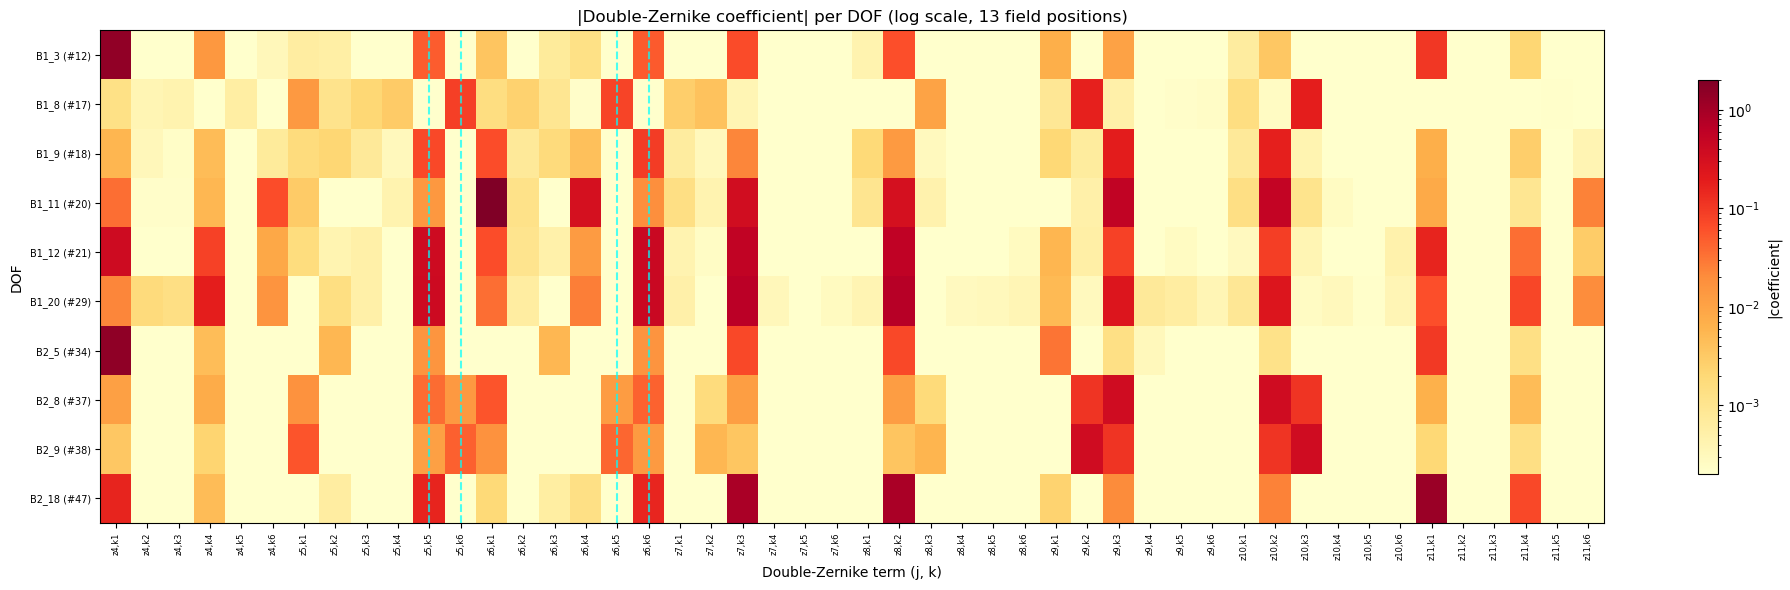

In [13]:
# Heatmap: |DZ coefficient| for all DOFs and all (j, k) pairs
dz_flat = dz_coeff_all.reshape(n_dof, n_j * n_k)  # (50, n_j * n_k)

dz_flat_labels = []
for j_noll in range(j_min, j_max + 1):
    for k in range(1, k_fp_max + 1):
        dz_flat_labels.append(f'z{j_noll},k{k}')

# Mark target columns
target_cols = []
for j_t, k_t in target_dz_terms:
    col_idx = (j_t - j_min) * n_k + (k_t - 1)
    target_cols.append(col_idx)

# Only show DOFs with significant content for any target term
target_coeffs = dz_flat[:, target_cols]
max_target = np.max(np.abs(target_coeffs), axis=1)
significant_dofs = np.where(max_target > 0.01 * np.max(max_target))[0]

fig, ax = plt.subplots(figsize=(20, max(6, len(significant_dofs) * 0.3)))
data = np.abs(dz_flat[significant_dofs, :])
vmax = np.max(data)
im = ax.imshow(data, aspect='auto', cmap='YlOrRd',
               norm=colors.LogNorm(vmin=max(1e-8, vmax * 1e-4), vmax=vmax))
ax.set_yticks(range(len(significant_dofs)),
              [f'{labels_50dof[d]} (#{d})' for d in significant_dofs], fontsize=7)
ax.set_xticks(range(len(dz_flat_labels)), dz_flat_labels, rotation=90, fontsize=6)
ax.set_xlabel('Double-Zernike term (j, k)')
ax.set_ylabel('DOF')
ax.set_title(f'|Double-Zernike coefficient| per DOF (log scale, {n_fp} field positions)')

for tc in target_cols:
    ax.axvline(tc, color='cyan', lw=1.5, alpha=0.7, ls='--')

fig.colorbar(im, ax=ax, shrink=0.8, label='|coefficient|')
fig.tight_layout()
plt.show()

# Linear-scale version of the same heatmap
fig, ax = plt.subplots(figsize=(20, max(6, len(significant_dofs) * 0.3)))
im = ax.imshow(data, aspect='auto', cmap='YlOrRd', vmin=0, vmax=vmax)
ax.set_yticks(range(len(significant_dofs)),
              [f'{labels_50dof[d]} (#{d})' for d in significant_dofs], fontsize=7)
ax.set_xticks(range(len(dz_flat_labels)), dz_flat_labels, rotation=90, fontsize=6)
ax.set_xlabel('Double-Zernike term (j, k)')
ax.set_ylabel('DOF')
ax.set_title(f'|Double-Zernike coefficient| per DOF (linear scale, {n_fp} field positions)')

for tc in target_cols:
    ax.axvline(tc, color='cyan', lw=1.5, alpha=0.7, ls='--')

fig.colorbar(im, ax=ax, shrink=0.8, label='|coefficient|')
fig.tight_layout()
plt.show()

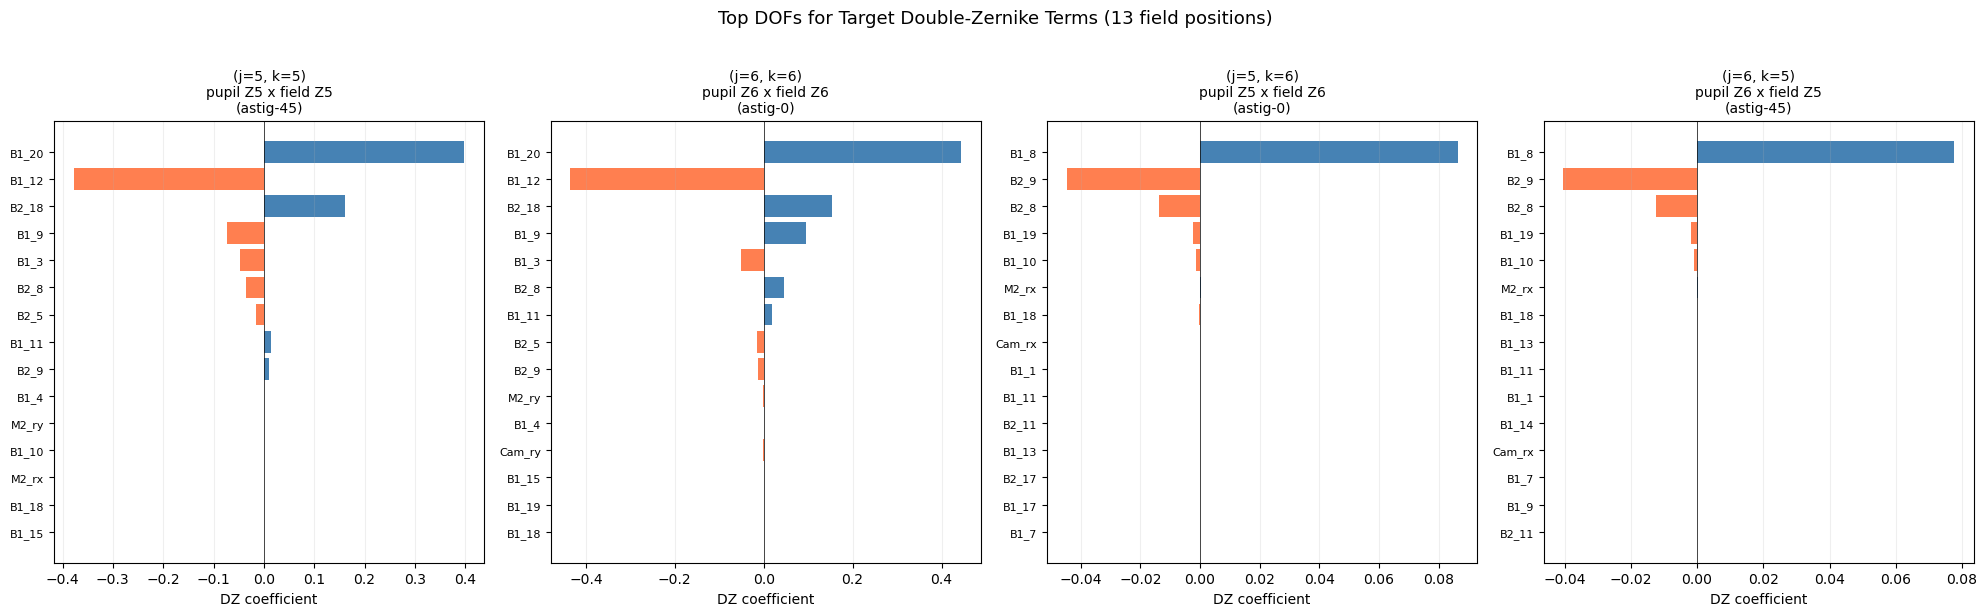

In [14]:
# Bar chart: top DOFs for each target DZ term
n_targets = len(target_dz_terms)
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 6))
if n_targets == 1:
    axes = [axes]

n_show = 15

for idx, ((j_t, k_t), ax) in enumerate(zip(target_dz_terms, axes)):
    j_local = j_t - j_min
    k_local = k_t - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    order = np.argsort(np.abs(coeffs))[::-1][:n_show]
    
    vals = coeffs[order]
    names = [f'{labels_50dof[d]}' for d in order]
    bar_colors = ['steelblue' if v >= 0 else 'coral' for v in vals]
    
    ax.barh(range(n_show), vals, color=bar_colors)
    ax.set_yticks(range(n_show), names, fontsize=8)
    ax.set_xlabel('DZ coefficient')
    ax.set_title(f'(j={j_t}, k={k_t})\npupil Z{j_t} x field Z{k_t}\n({fp_zernike_names[k_t]})',
                fontsize=10)
    ax.axvline(0, color='k', lw=0.5)
    ax.grid(alpha=0.2, axis='x')
    ax.invert_yaxis()

fig.suptitle(f'Top DOFs for Target Double-Zernike Terms ({n_fp} field positions)',
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

<a id='verification'></a>
## 7. DOF Wavefront Pattern Verification

This section verifies that the top-ranked DOFs from the double-Zernike decomposition
(Section 6) actually produce the expected astigmatic field patterns.

**Focused Z5 / Z6 figures (next two cells):**
Each figure has two rows.
- **Top row:** The expected focal-plane Zernike patterns Z4 (defocus), Z5 (astig-45),
  and Z6 (astig-0) evaluated at all field positions. The color is the *dimensionless
  Zernike polynomial value* at each point's normalized (\u03c1, \u03b8) coordinates.
  This is the pattern we expect to see if a DOF has pure k=4, k=5, or k=6 field dependence.
- **Bottom row:** The *actual* pupil Zernike sensitivity (Z5 or Z6) from the sensitivity
  matrix at each field position, for the top 3 DOFs identified in Section 6.
  The color is in **\u03bcm of wavefront per unit DOF** (\u03bcm for translations/bending modes,
  arcsec for rotations). If a DOF truly produces a (j=5, k=5) pattern, the bottom-row
  pattern should resemble the Z5 panel in the top row, scaled by the DZ coefficient.

**Detailed heatmap + line plots (subsequent cells):**
For each target DZ term, plots for the top 3 DOFs show:
- *Left panel:* Heatmap of all pupil Zernike sensitivities at all field positions.
  Color is \u03bcm of wavefront per unit DOF motion.
- *Right panel:* The target pupil Zernike (e.g. Z5) sensitivity across field positions
  (blue circles), compared to the expected focal-plane Zernike pattern scaled by the
  best-fit DZ coefficient (coral squares), and the full DZ fit using all k terms (gray).

**Focal-plane scatter plots:**
For each target DZ term, the first panel shows the expected dimensionless field Zernike
pattern; subsequent panels show the actual sensitivity (\u03bcm/unit DOF) of each top DOF
at all field positions, plotted on the focal plane.

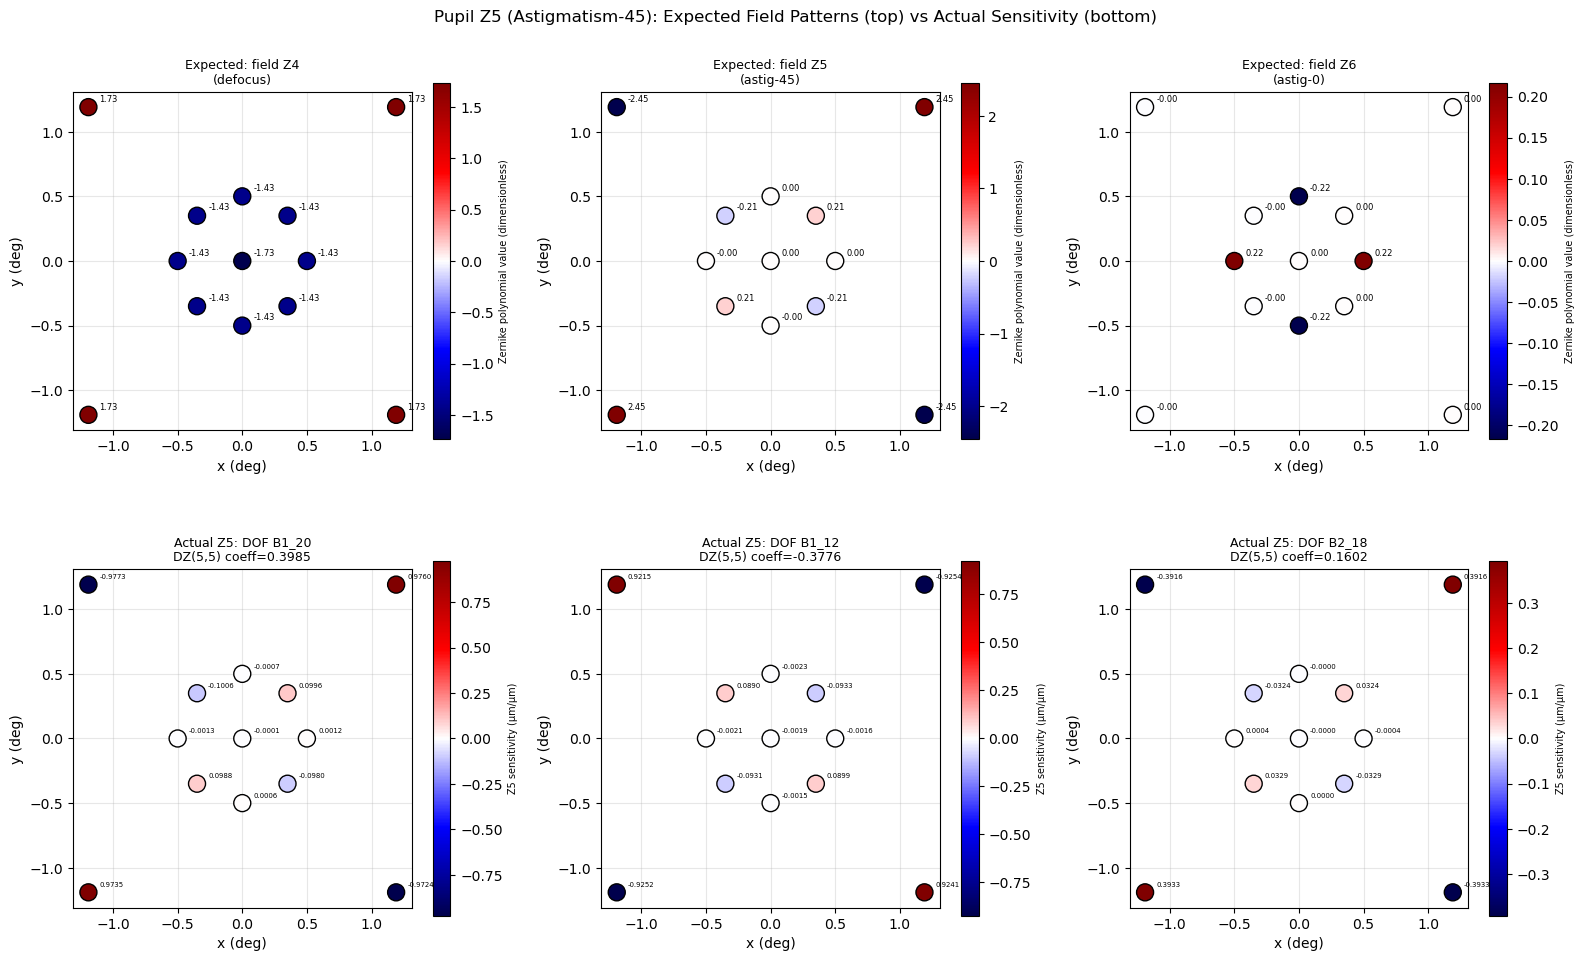

In [15]:
# Focused figure: Pupil Z5 (astigmatism-45) field variation patterns
# Top row: expected focal-plane Zernike patterns Z4, Z5, Z6 (dimensionless)
# Bottom row: actual Z5 sensitivity from top DOFs (microns per unit DOF)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Top row: show Z4, Z5, Z6 focal-plane patterns (the quadratic terms most relevant for astigmatism)
for col_idx, k in enumerate([4, 5, 6]):
    ax = axes[0, col_idx]
    vals = fp_zernike_vals[k]
    vmax = max(np.max(np.abs(vals)), 0.01)
    scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=vals, cmap='seismic',
                         vmin=-vmax, vmax=vmax, s=150, edgecolors='k', zorder=5)
    for i in range(n_fp):
        ax.annotate(f'{vals[i]:.2f}', (fp_xy[i, 0], fp_xy[i, 1]),
                    textcoords='offset points', xytext=(8, 4), fontsize=6)
    ax.set_title(f'Expected: field Z{k}\n({fp_zernike_names[k]})', fontsize=9)
    ax.set_xlabel('x (deg)')
    ax.set_ylabel('y (deg)')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
    cb.set_label('Zernike polynomial value (dimensionless)', fontsize=7)

# Bottom row: actual Z5 sensitivity at field positions for top 3 DOFs for (5,5)
j_target = 5
j_local = j_target - j_min
k_target = 5
k_local = k_target - 1
coeffs_55 = dz_coeff_all[:, j_local, k_local]
order_55 = np.argsort(np.abs(coeffs_55))[::-1]
match_j = np.where(zn == j_target)[0]

if len(match_j) > 0:
    p_j = match_j[0]
    for rank_i in range(min(3, len(order_55))):
        d = order_55[rank_i]
        ax = axes[1, rank_i]
        a_j_field = A_3d[:, p_j, d]
        dof_unit = dof_units_50[d]
        vmax_d = max(np.max(np.abs(a_j_field)), 1e-10)
        scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=a_j_field,
                             cmap='seismic', vmin=-vmax_d, vmax=vmax_d,
                             s=150, edgecolors='k', zorder=5)
        for i in range(n_fp):
            ax.annotate(f'{a_j_field[i]:.4f}', (fp_xy[i, 0], fp_xy[i, 1]),
                        textcoords='offset points', xytext=(8, 4), fontsize=5)
        ax.set_title(f'Actual Z5: DOF {labels_50dof[d]}\nDZ(5,5) coeff={coeffs_55[d]:.4f}',
                     fontsize=9)
        ax.set_xlabel('x (deg)')
        ax.set_ylabel('y (deg)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
        cb.set_label(f'Z5 sensitivity (\u03bcm/{dof_unit})', fontsize=7)

fig.suptitle('Pupil Z5 (Astigmatism-45): Expected Field Patterns (top) vs Actual Sensitivity (bottom)',
             fontsize=12)
fig.tight_layout()
plt.show()

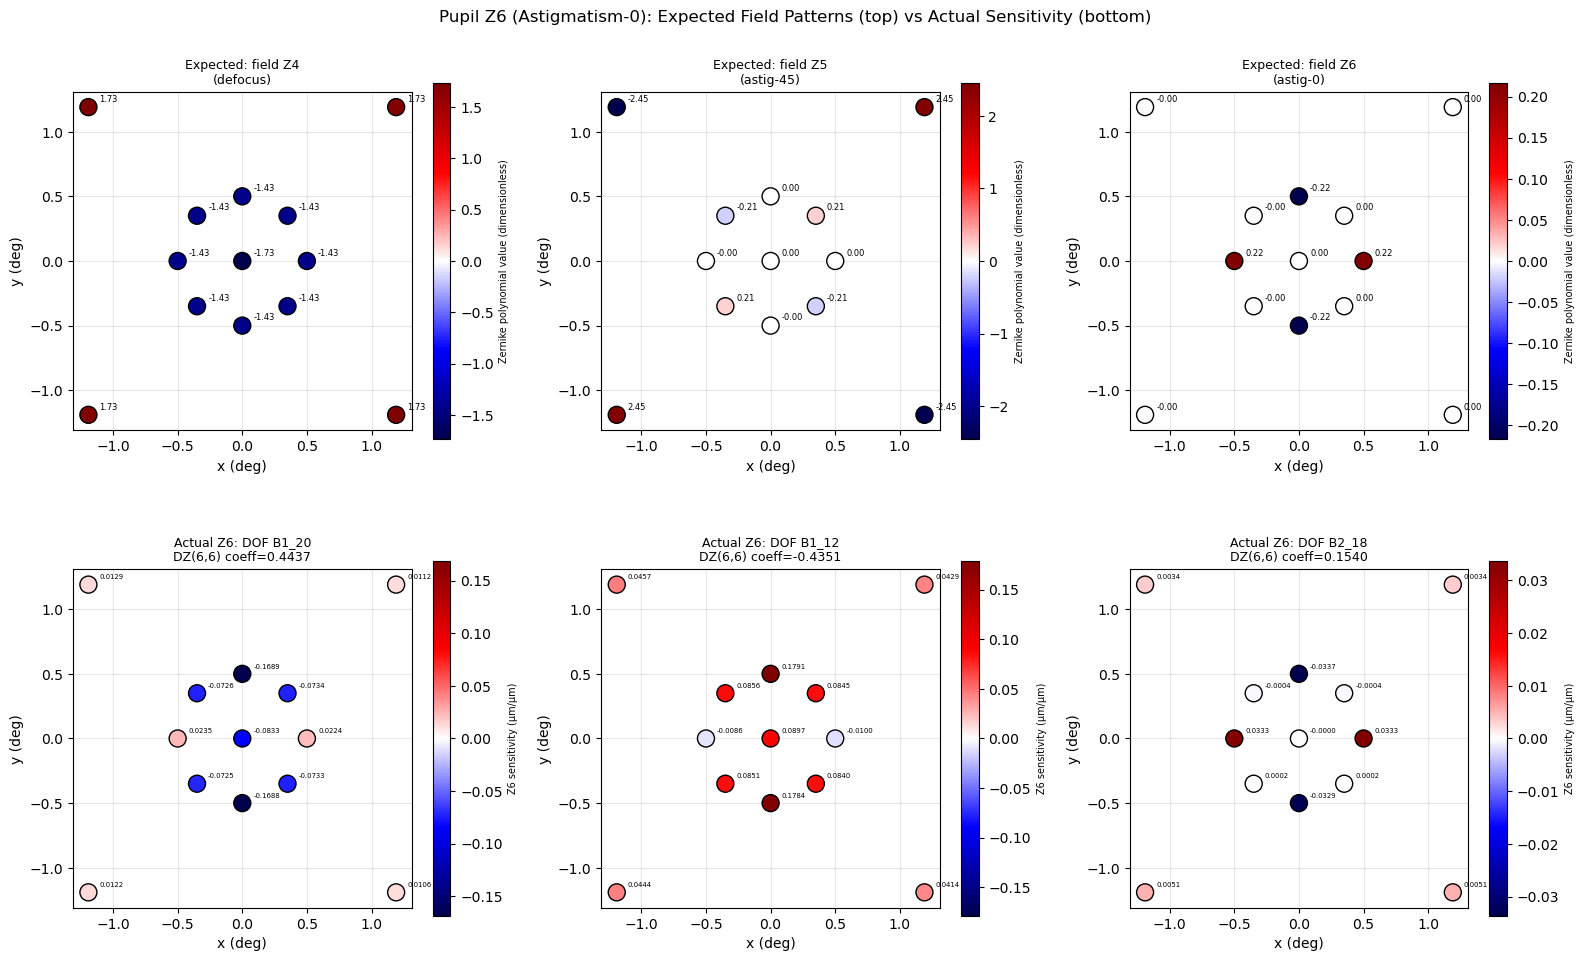

In [16]:
# Focused figure: Pupil Z6 (astigmatism-0) field variation patterns
# Top row: expected focal-plane Zernike patterns Z4, Z5, Z6 (dimensionless)
# Bottom row: actual Z6 sensitivity from top DOFs (microns per unit DOF)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Top row: show Z4, Z5, Z6 focal-plane patterns
for col_idx, k in enumerate([4, 5, 6]):
    ax = axes[0, col_idx]
    vals = fp_zernike_vals[k]
    vmax = max(np.max(np.abs(vals)), 0.01)
    scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=vals, cmap='seismic',
                         vmin=-vmax, vmax=vmax, s=150, edgecolors='k', zorder=5)
    for i in range(n_fp):
        ax.annotate(f'{vals[i]:.2f}', (fp_xy[i, 0], fp_xy[i, 1]),
                    textcoords='offset points', xytext=(8, 4), fontsize=6)
    ax.set_title(f'Expected: field Z{k}\n({fp_zernike_names[k]})', fontsize=9)
    ax.set_xlabel('x (deg)')
    ax.set_ylabel('y (deg)')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
    cb.set_label('Zernike polynomial value (dimensionless)', fontsize=7)

# Bottom row: actual Z6 sensitivity at field positions for top 3 DOFs for (6,6)
j_target = 6
j_local = j_target - j_min
k_target = 6
k_local = k_target - 1
coeffs_66 = dz_coeff_all[:, j_local, k_local]
order_66 = np.argsort(np.abs(coeffs_66))[::-1]
match_j = np.where(zn == j_target)[0]

if len(match_j) > 0:
    p_j = match_j[0]
    for rank_i in range(min(3, len(order_66))):
        d = order_66[rank_i]
        ax = axes[1, rank_i]
        a_j_field = A_3d[:, p_j, d]
        dof_unit = dof_units_50[d]
        vmax_d = max(np.max(np.abs(a_j_field)), 1e-10)
        scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=a_j_field,
                             cmap='seismic', vmin=-vmax_d, vmax=vmax_d,
                             s=150, edgecolors='k', zorder=5)
        for i in range(n_fp):
            ax.annotate(f'{a_j_field[i]:.4f}', (fp_xy[i, 0], fp_xy[i, 1]),
                        textcoords='offset points', xytext=(8, 4), fontsize=5)
        ax.set_title(f'Actual Z6: DOF {labels_50dof[d]}\nDZ(6,6) coeff={coeffs_66[d]:.4f}',
                     fontsize=9)
        ax.set_xlabel('x (deg)')
        ax.set_ylabel('y (deg)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
        cb.set_label(f'Z6 sensitivity (\u03bcm/{dof_unit})', fontsize=7)

fig.suptitle('Pupil Z6 (Astigmatism-0): Expected Field Patterns (top) vs Actual Sensitivity (bottom)',
             fontsize=12)
fig.tight_layout()
plt.show()

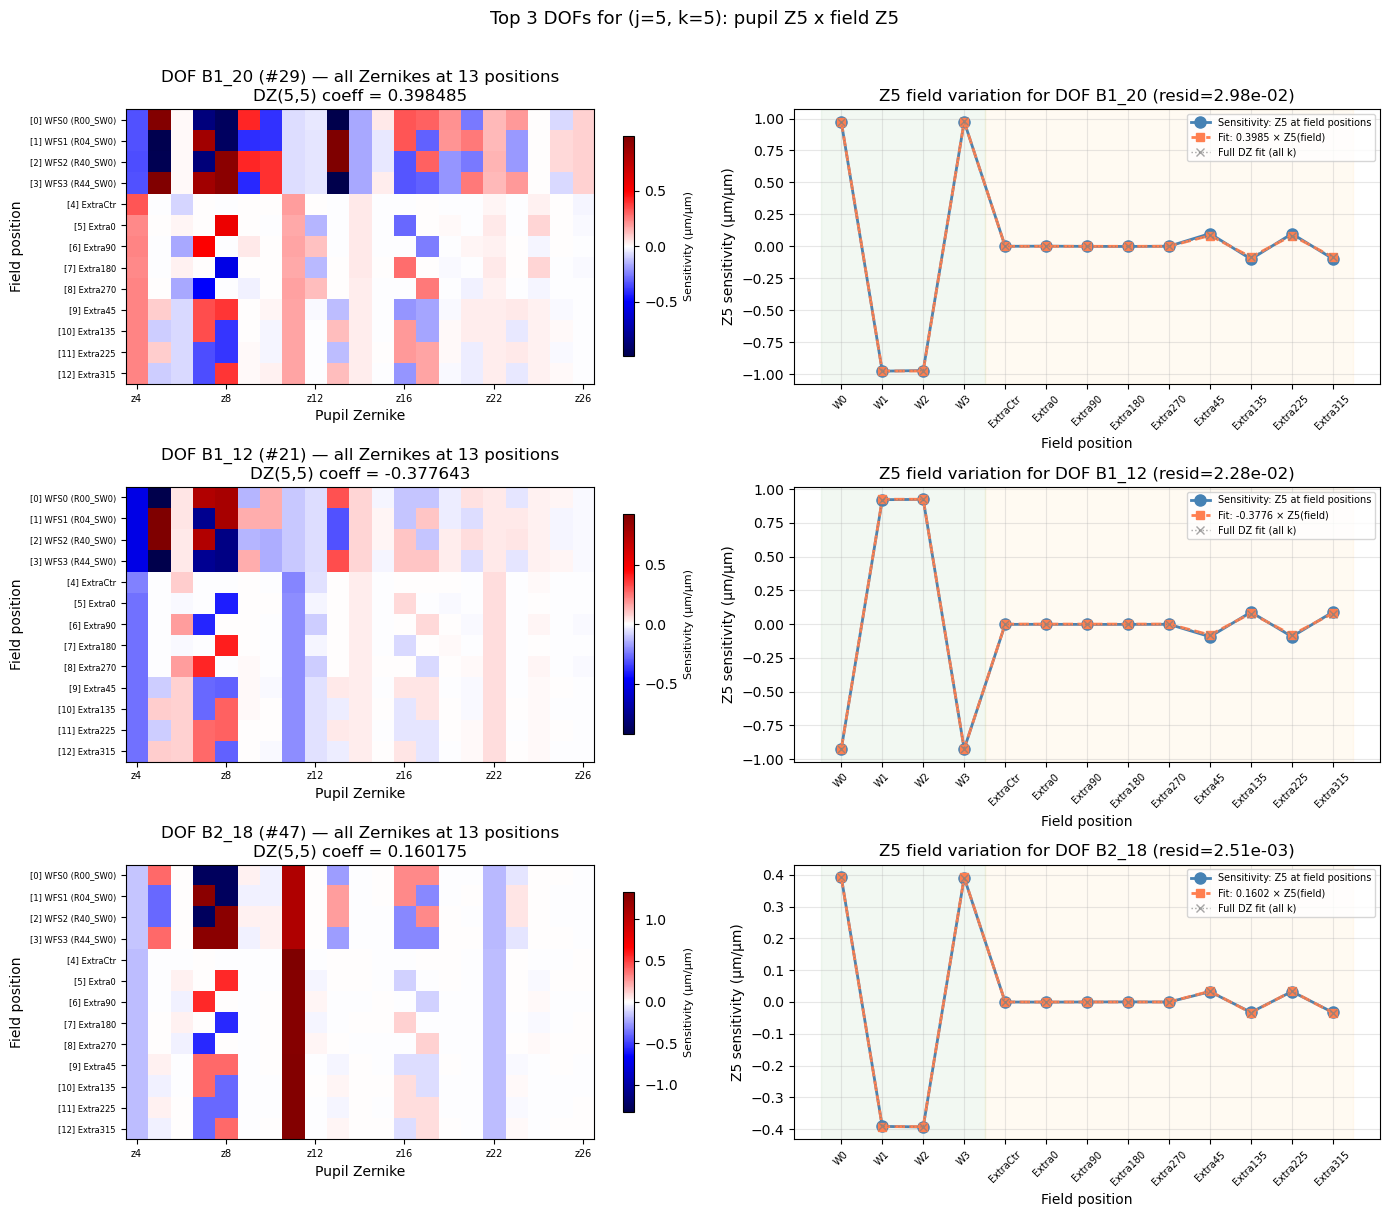

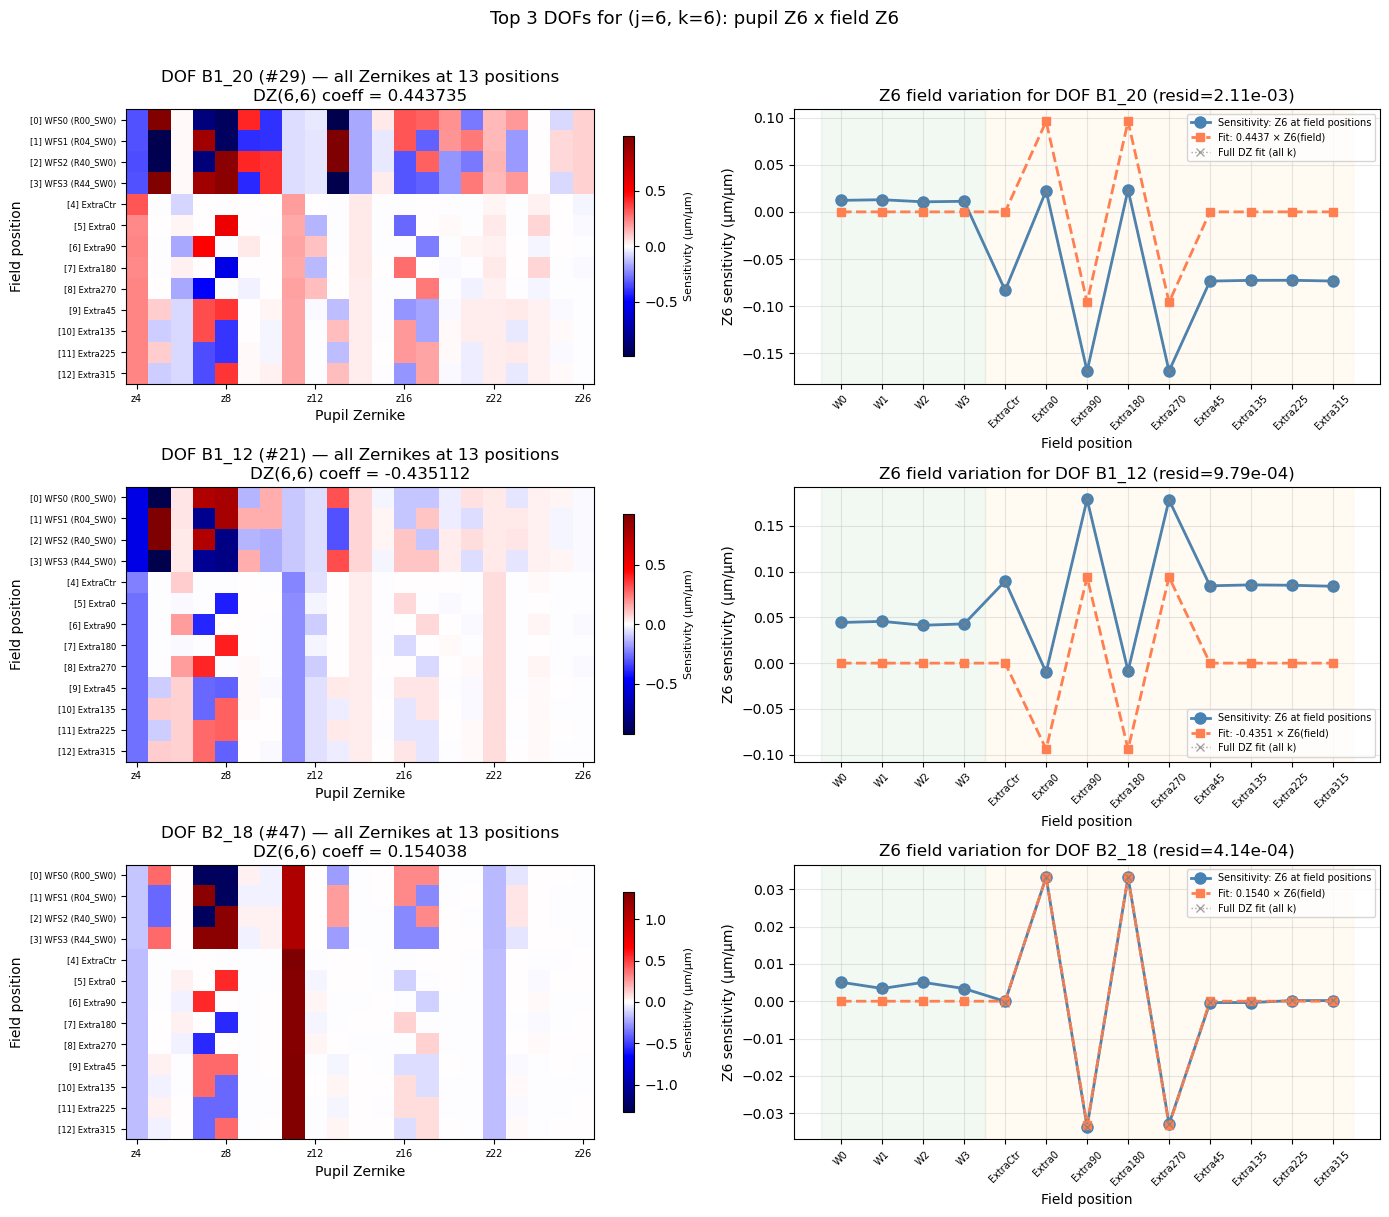

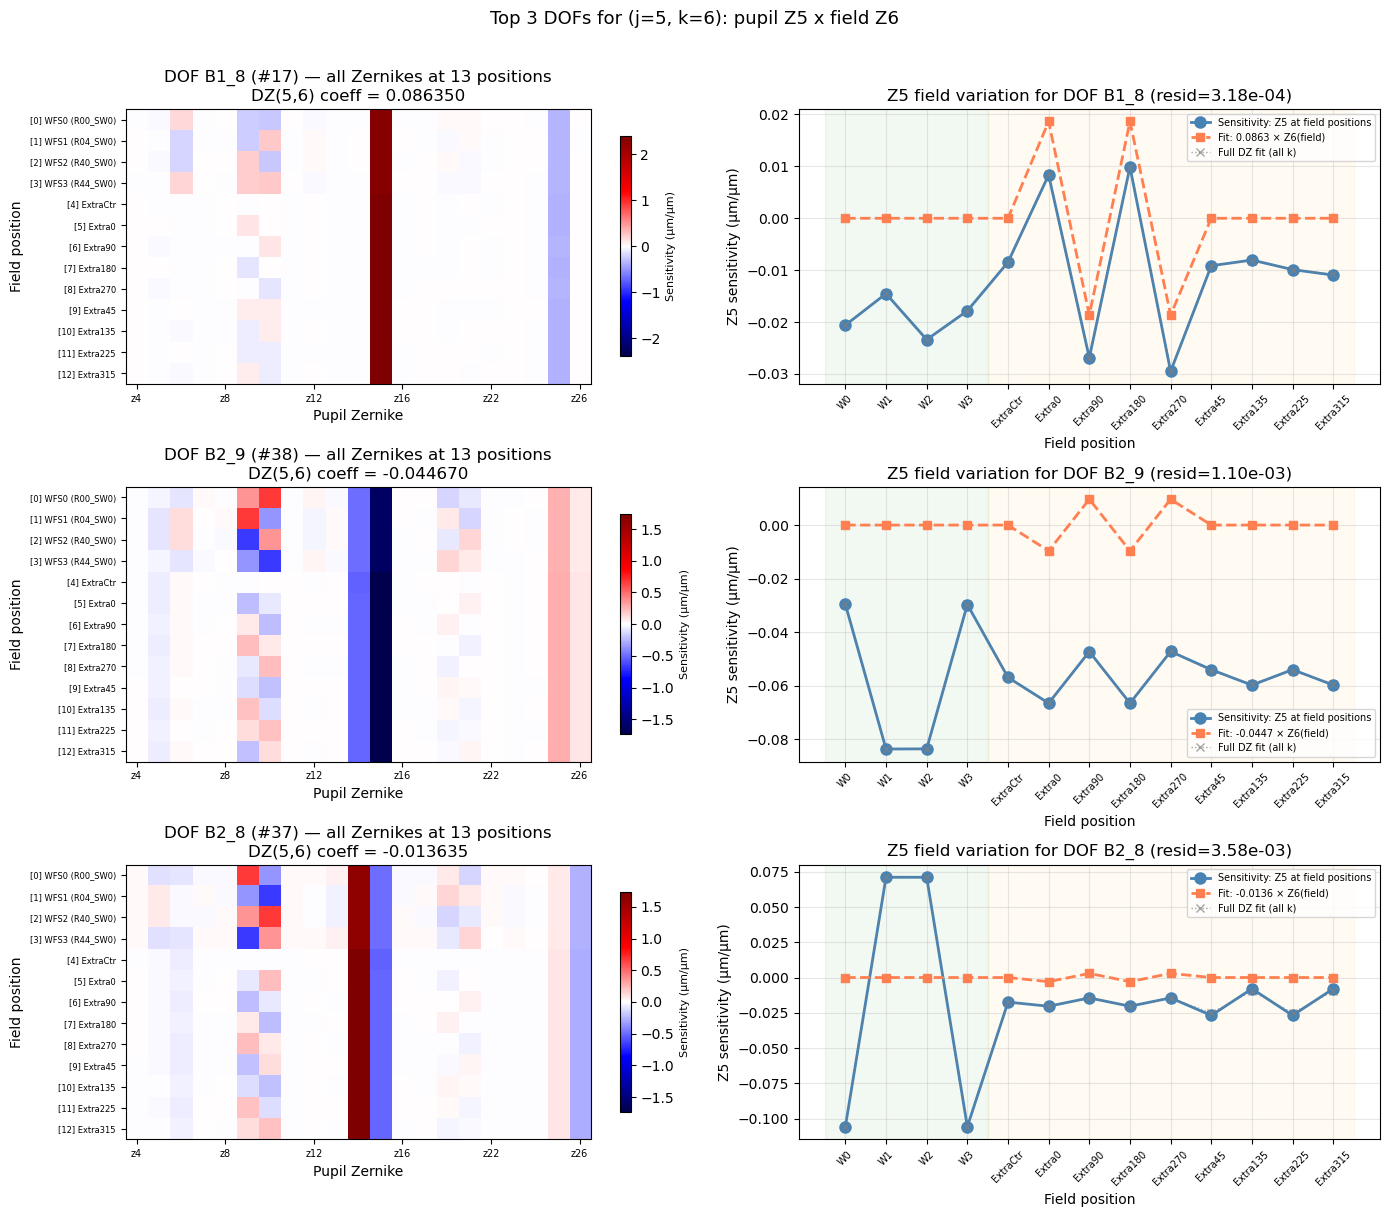

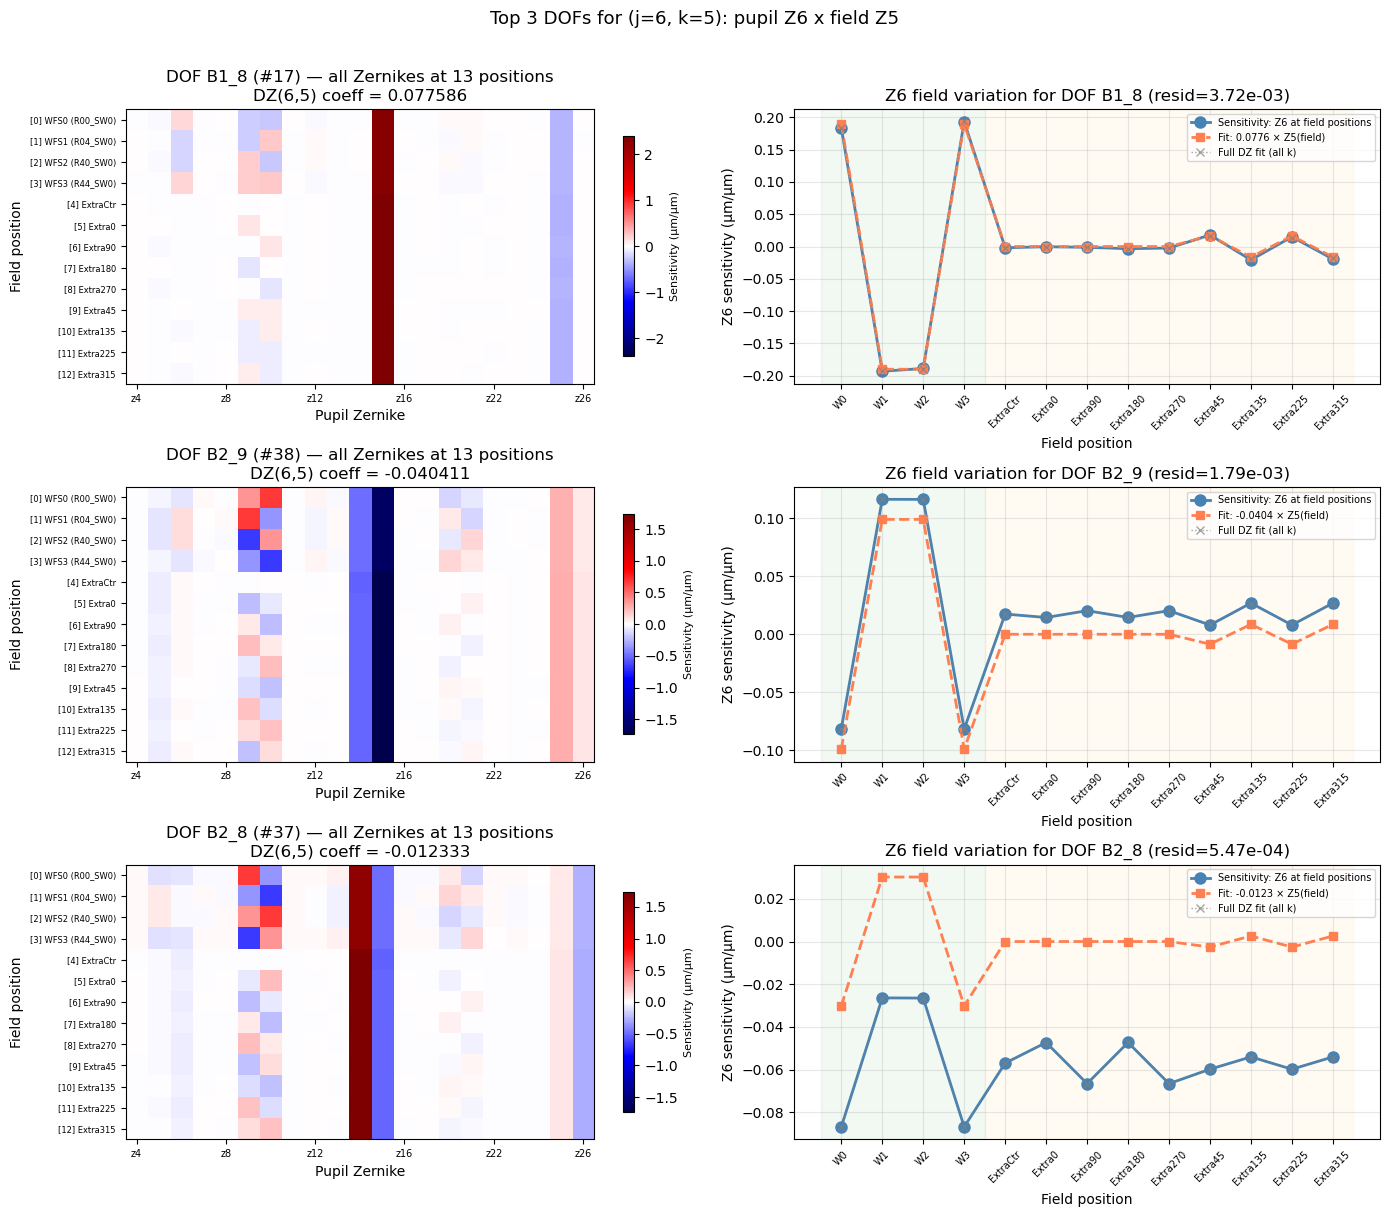

In [17]:
# For each target DZ term, show the wavefront pattern of the top 3 DOFs
n_top = 3

for j_target, k_target in target_dz_terms:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    order = np.argsort(np.abs(coeffs))[::-1][:n_top]
    
    fig, axes = plt.subplots(n_top, 2, figsize=(14, 4 * n_top))
    
    for rank_i, d in enumerate(order):
        if np.abs(coeffs[d]) < 1e-10:
            continue
        dof_unit = dof_units_50[d]
        
        # Left panel: Zernike coefficients at ALL field positions (heatmap)
        ax_heat = axes[rank_i, 0]
        a_col = A_3d[:, :, d]  # shape (n_fp, n_zernike)
        vmax = np.max(np.abs(a_col))
        im = ax_heat.imshow(a_col, cmap='seismic', aspect='auto', vmin=-vmax, vmax=vmax)
        ax_heat.set_ylabel('Field position')
        ax_heat.set_yticks(range(n_fp),
                           [f'[{i}] {fp_labels[i][:15]}' for i in range(n_fp)], fontsize=6)
        zern_ticks = range(0, n_zernike, 4)
        ax_heat.set_xticks(list(zern_ticks), [f'z{zn[i]}' for i in zern_ticks], fontsize=7)
        ax_heat.set_xlabel('Pupil Zernike')
        ax_heat.set_title(f'DOF {labels_50dof[d]} (#{d}) \u2014 all Zernikes at {n_fp} positions\n'
                         f'DZ({j_target},{k_target}) coeff = {coeffs[d]:.6f}')
        cb = fig.colorbar(im, ax=ax_heat, shrink=0.8)
        cb.set_label(f'Sensitivity (\u03bcm/{dof_unit})', fontsize=8)
        
        # Right panel: Z_j coefficient vs field position, with expected Z_k pattern
        ax_line = axes[rank_i, 1]
        match_j = np.where(zn == j_target)[0]
        if len(match_j) > 0:
            p_j = match_j[0]
            a_j_at_field = A_3d[:, p_j, d]  # shape (n_fp,)
            
            ax_line.plot(range(n_fp), a_j_at_field, 'o-', color='steelblue',
                        markersize=8, lw=2, label=f'Sensitivity: Z{j_target} at field positions')
            
            # Expected pattern from Z_k field dependence (scaled by best-fit coeff)
            fp_pattern = fp_zernike_vals[k_target]
            scale = coeffs[d]
            ax_line.plot(range(n_fp), scale * fp_pattern, 's--', color='coral',
                        markersize=6, lw=2, label=f'Fit: {scale:.4f} \u00d7 Z{k_target}(field)')
            
            # Also show the full fit (all k)
            full_fit = FP_design @ dz_coeff_all[d, j_local, :]
            ax_line.plot(range(n_fp), full_fit, 'x:', color='gray', markersize=6,
                        lw=1, label='Full DZ fit (all k)', alpha=0.7)
            
            # Mark WFS vs extra points
            ax_line.axvspan(-0.5, n_wfs - 0.5, alpha=0.05, color='green')
            ax_line.axvspan(n_wfs - 0.5, n_fp - 0.5, alpha=0.05, color='orange')
            
            short_labels = ([f'W{i}' for i in range(n_wfs)] +
                           [lbl[:8] for lbl in extra_field_labels])
            ax_line.set_xticks(range(n_fp), short_labels, fontsize=7, rotation=45)
            ax_line.set_ylabel(f'Z{j_target} sensitivity (\u03bcm/{dof_unit})')
            ax_line.set_xlabel('Field position')
            ax_line.legend(fontsize=7, loc='best')
            ax_line.grid(alpha=0.3)
            resid = dz_residual_all[d, j_local]
            ax_line.set_title(f'Z{j_target} field variation for DOF {labels_50dof[d]}'
                             f' (resid={resid:.2e})')
    
    fig.suptitle(f'Top {n_top} DOFs for (j={j_target}, k={k_target}): '
                f'pupil Z{j_target} x field Z{k_target}',
                fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()

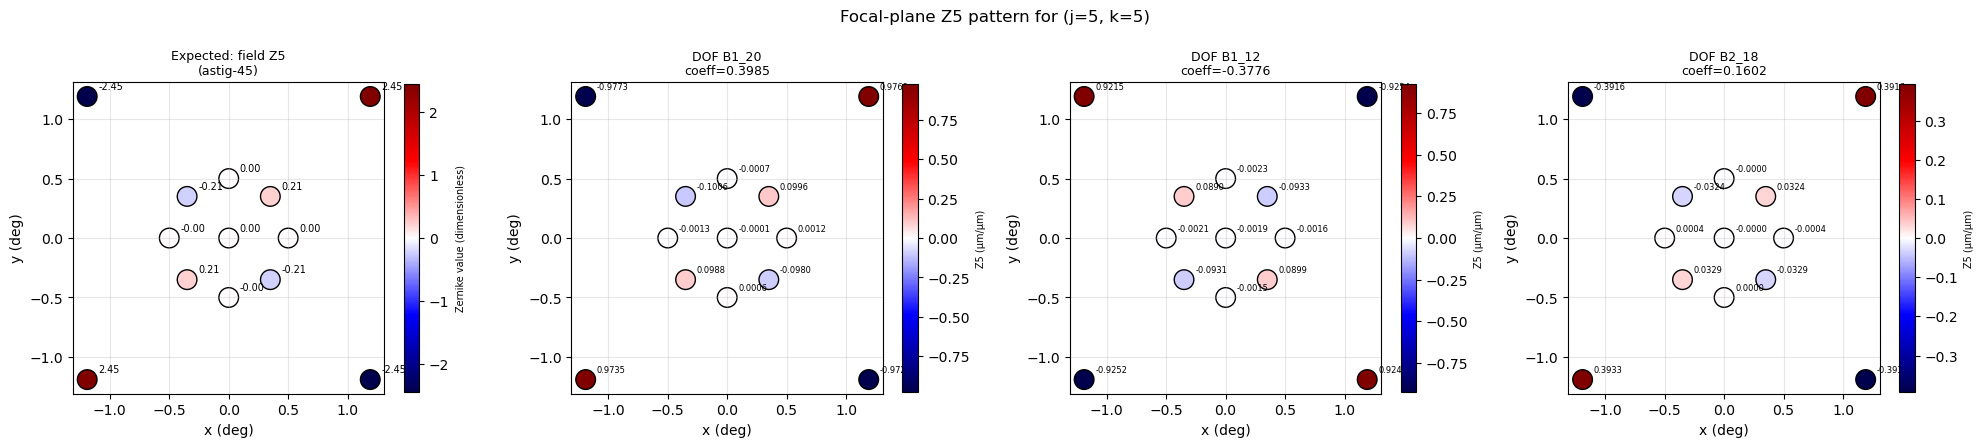

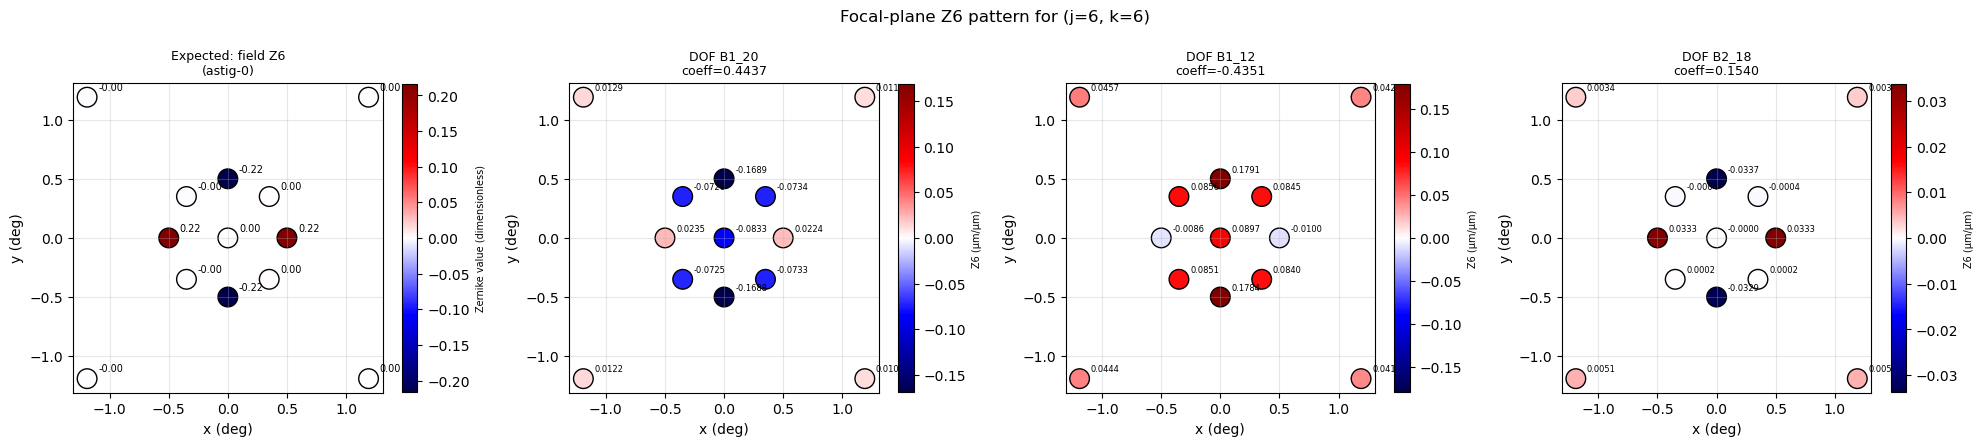

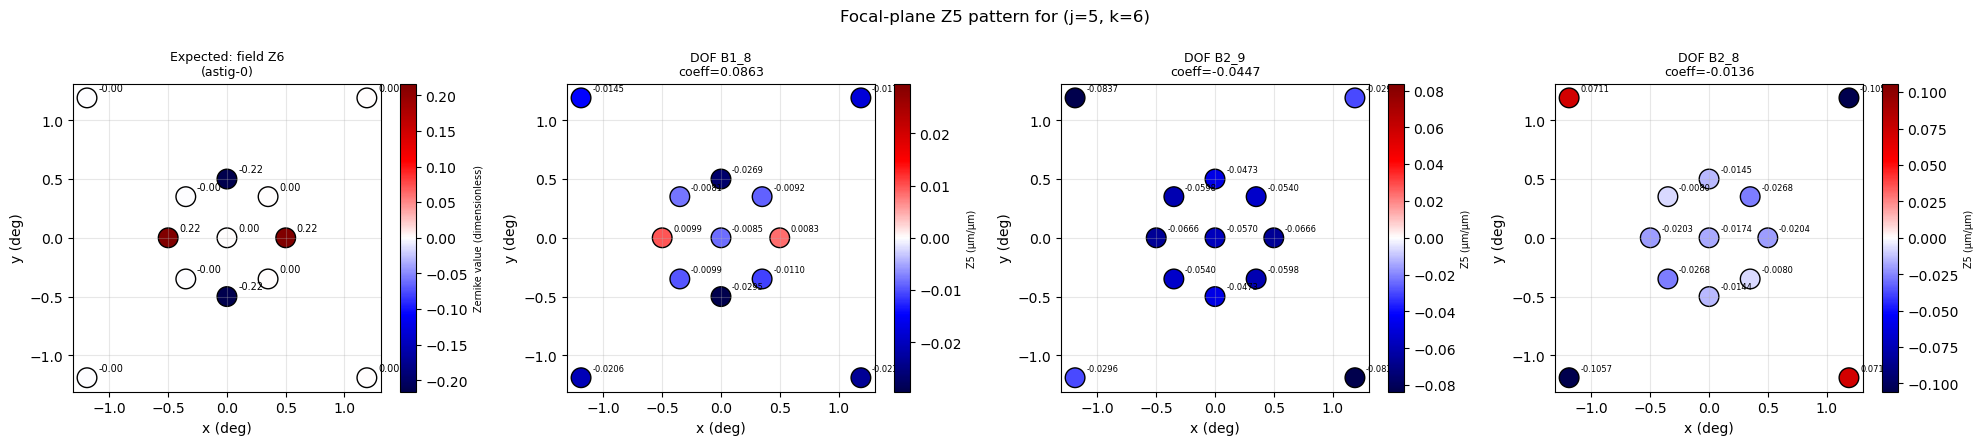

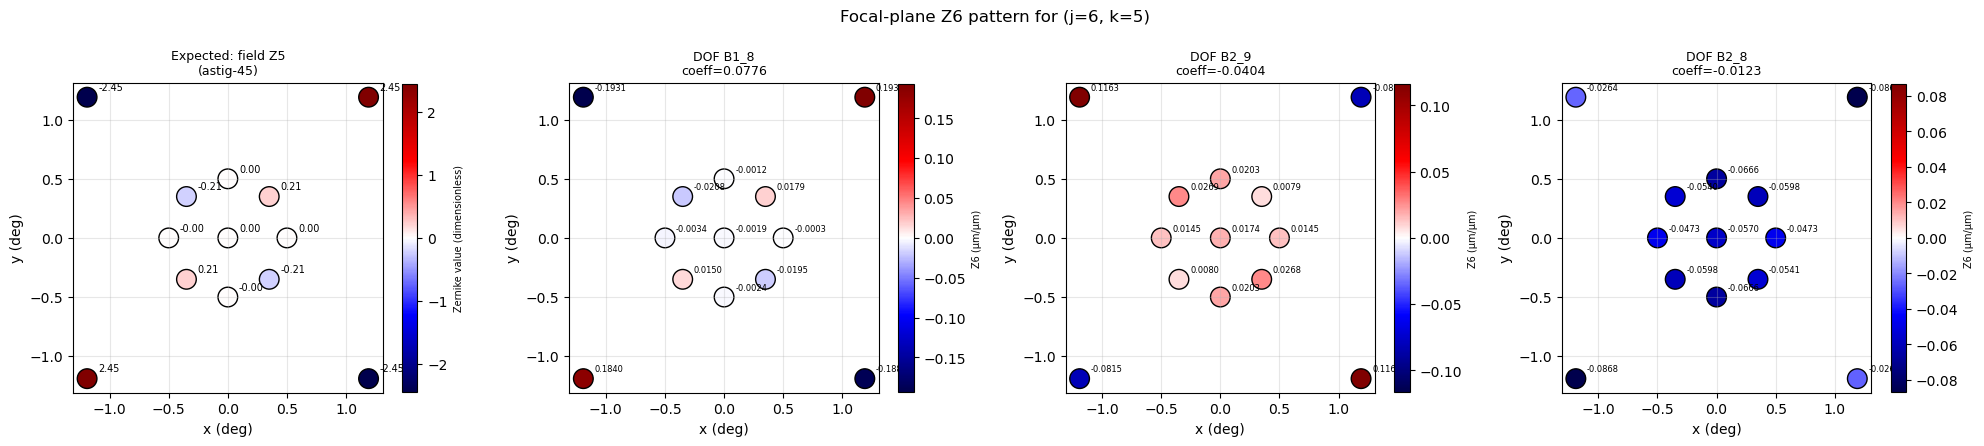

In [18]:
# Focal-plane scatter plots: show Z_j amplitude at each field position for top DOFs
for j_target, k_target in target_dz_terms:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    order = np.argsort(np.abs(coeffs))[::-1][:n_top]
    
    fig, axes = plt.subplots(1, n_top + 1, figsize=(5 * (n_top + 1), 4.5))
    
    # First panel: expected Z_k pattern on the focal plane (dimensionless)
    ax = axes[0]
    vals = fp_zernike_vals[k_target]
    vmax = max(np.max(np.abs(vals)), 0.01)
    scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=vals, cmap='seismic',
                         vmin=-vmax, vmax=vmax, s=200, edgecolors='k')
    for i in range(n_fp):
        ax.annotate(f'{vals[i]:.2f}', (fp_xy[i, 0], fp_xy[i, 1]),
                    textcoords='offset points', xytext=(8, 5), fontsize=7)
    ax.set_title(f'Expected: field Z{k_target}\n({fp_zernike_names[k_target]})', fontsize=9)
    ax.set_xlabel('x (deg)')
    ax.set_ylabel('y (deg)')
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)
    cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
    cb.set_label('Zernike value (dimensionless)', fontsize=7)
    
    # Remaining panels: actual Z_j values for each top DOF (physical units)
    match_j = np.where(zn == j_target)[0]
    if len(match_j) > 0:
        p_j = match_j[0]
        for rank_i, d in enumerate(order):
            ax = axes[rank_i + 1]
            a_j_field = A_3d[:, p_j, d]
            dof_unit = dof_units_50[d]
            vmax_d = max(np.max(np.abs(a_j_field)), 1e-10)
            scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=a_j_field,
                                 cmap='seismic', vmin=-vmax_d, vmax=vmax_d,
                                 s=200, edgecolors='k')
            for i in range(n_fp):
                ax.annotate(f'{a_j_field[i]:.4f}', (fp_xy[i, 0], fp_xy[i, 1]),
                            textcoords='offset points', xytext=(8, 5), fontsize=6)
            ax.set_title(f'DOF {labels_50dof[d]}\ncoeff={coeffs[d]:.4f}', fontsize=9)
            ax.set_xlabel('x (deg)')
            ax.set_ylabel('y (deg)')
            ax.set_aspect('equal')
            ax.grid(alpha=0.3)
            cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
            cb.set_label(f'Z{j_target} (\u03bcm/{dof_unit})', fontsize=7)
    
    fig.suptitle(f'Focal-plane Z{j_target} pattern for (j={j_target}, k={k_target})',
                fontsize=12)
    fig.tight_layout()
    plt.show()

In [19]:
# Full DZ decomposition for the top DOF of each target term
for j_target, k_target in target_dz_terms:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    d_best = np.argmax(np.abs(coeffs))
    
    print(f'\n{"=" * 70}')
    print(f'Best DOF for (j={j_target}, k={k_target}): {labels_50dof[d_best]} (#{d_best})')
    print(f'{"=" * 70}')
    print(f'Full DZ decomposition of DOF {labels_50dof[d_best]}:')
    print(f'{"j":>4s} {"k":>4s} {"coeff":>12s} {"abs":>12s}  description')
    print('-' * 65)
    
    all_coeffs = dz_coeff_all[d_best, :, :]
    for j_local_i in range(n_j):
        j_noll = j_min + j_local_i
        for k_local_i in range(n_k):
            k_noll = 1 + k_local_i
            c = all_coeffs[j_local_i, k_local_i]
            if np.abs(c) > 1e-8:
                marker = '  <-- TARGET' if (j_noll, k_noll) in target_dz_terms else ''
                print(f'{j_noll:4d} {k_noll:4d} {c:12.6f} {np.abs(c):12.6f}  '
                      f'pupil Z{j_noll} x field Z{k_noll} ({fp_zernike_names[k_noll]}){marker}')


Best DOF for (j=5, k=5): B1_20 (#29)
Full DZ decomposition of DOF B1_20:
   j    k        coeff          abs  description
-----------------------------------------------------------------
   4    1    -0.023354     0.023354  pupil Z4 x field Z1 (piston)
   4    2    -0.001727     0.001727  pupil Z4 x field Z2 (x-tilt)
   4    3     0.001404     0.001404  pupil Z4 x field Z3 (y-tilt)
   4    4    -0.183051     0.183051  pupil Z4 x field Z4 (defocus)
   4    5    -0.000004     0.000004  pupil Z4 x field Z5 (astig-45)
   4    6    -0.015795     0.015795  pupil Z4 x field Z6 (astig-0)
   5    1    -0.000040     0.000040  pupil Z5 x field Z1 (piston)
   5    2     0.001413     0.001413  pupil Z5 x field Z2 (x-tilt)
   5    3    -0.000517     0.000517  pupil Z5 x field Z3 (y-tilt)
   5    4     0.000011     0.000011  pupil Z5 x field Z4 (defocus)
   5    5     0.398485     0.398485  pupil Z5 x field Z5 (astig-45)  <-- TARGET
   5    6     0.000023     0.000023  pupil Z5 x field Z6 (astig-0)

<a id='physical-impact'></a>
## 8. Physical Impact at Field Points

For each DOF identified in Section 6 as producing astigmatic field patterns,
compute the **actual wavefront change** (in \u03bcm) at every field position given
a realistic DOF perturbation amplitude.

For **bending modes** (B1_\*, B2_\*), we use an amplitude of **0.5 \u03bcm**.
For **rigid-body translations** (dz, dx, dy), we use **1.0 \u03bcm**.
For **rigid-body rotations** (rx, ry), we use **1.0 arcsec**.

This answers the practical question: if a given DOF changes by a physically
meaningful amount, how much Z5 and Z6 wavefront change appears at each
field position?

In [20]:
# Physical impact: Z5 and Z6 wavefront change at each field position
# for a physically meaningful DOF perturbation.

# Perturbation amplitudes per DOF type
dof_perturbation = np.zeros(n_dof)
for d in range(n_dof):
    if dof_units_50[d] == 'arcsec':
        dof_perturbation[d] = 1.0   # 1 arcsec for rotations
    else:
        if d >= 10:  # bending modes
            dof_perturbation[d] = 0.5  # 0.5 microns for bending modes
        else:  # rigid body translations
            dof_perturbation[d] = 1.0  # 1.0 microns for translations

# Compute wavefront change for each DOF at each field position
# delta_wfe[s, p, d] = A_3d[s, p, d] * perturbation[d]  (units: microns)

# Indices for Z5 and Z6 in the zn array
p_z5 = np.where(zn == 5)[0][0]
p_z6 = np.where(zn == 6)[0][0]

# For each target DZ term, find relevant DOFs and compute impact
print('Physical Impact Analysis')
print('=' * 100)
print(f'Bending mode amplitude: 0.5 \u03bcm   |   Translation amplitude: 1.0 \u03bcm   |   Rotation amplitude: 1.0 arcsec')
print()

for j_target, k_target in [(5, 5), (6, 6), (5, 6), (6, 5)]:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    order = np.argsort(np.abs(coeffs))[::-1][:5]  # top 5 DOFs
    
    print(f'--- Target DZ({j_target},{k_target}): pupil Z{j_target} x field Z{k_target} ---')
    print(f'{"DOF":>12s} {"unit":>7s} {"perturb":>8s} {"max|\u0394Z5|":>10s} {"max|\u0394Z6|":>10s}  '
          f'{"rms \u0394Z5":>10s} {"rms \u0394Z6":>10s}')
    print('-' * 75)
    
    for d in order:
        if np.abs(coeffs[d]) < 1e-10:
            continue
        amp = dof_perturbation[d]
        dz5 = A_3d[:, p_z5, d] * amp  # microns of Z5 at each field position
        dz6 = A_3d[:, p_z6, d] * amp  # microns of Z6 at each field position
        print(f'{labels_50dof[d]:>12s} {dof_units_50[d]:>7s} {amp:8.2f} '
              f'{np.max(np.abs(dz5)):10.4f} {np.max(np.abs(dz6)):10.4f}  '
              f'{np.sqrt(np.mean(dz5**2)):10.4f} {np.sqrt(np.mean(dz6**2)):10.4f}')
    print()

Physical Impact Analysis
Bending mode amplitude: 0.5 μm   |   Translation amplitude: 1.0 μm   |   Rotation amplitude: 1.0 arcsec

--- Target DZ(5,5): pupil Z5 x field Z5 ---
         DOF    unit  perturb   max|ΔZ5|   max|ΔZ6|     rms ΔZ5    rms ΔZ6
---------------------------------------------------------------------------
       B1_20      μm     0.50     0.4886     0.0844      0.2718     0.0409
       B1_12      μm     0.50     0.4627     0.0895      0.2575     0.0457
       B2_18      μm     0.50     0.1967     0.0169      0.1092     0.0093
        B1_9      μm     0.50     0.0907     0.0463      0.0497     0.0345
        B1_3      μm     0.50     0.0597     0.0083      0.0329     0.0039

--- Target DZ(6,6): pupil Z6 x field Z6 ---
         DOF    unit  perturb   max|ΔZ5|   max|ΔZ6|     rms ΔZ5    rms ΔZ6
---------------------------------------------------------------------------
       B1_20      μm     0.50     0.4886     0.0844      0.2718     0.0409
       B1_12      μm     0.50

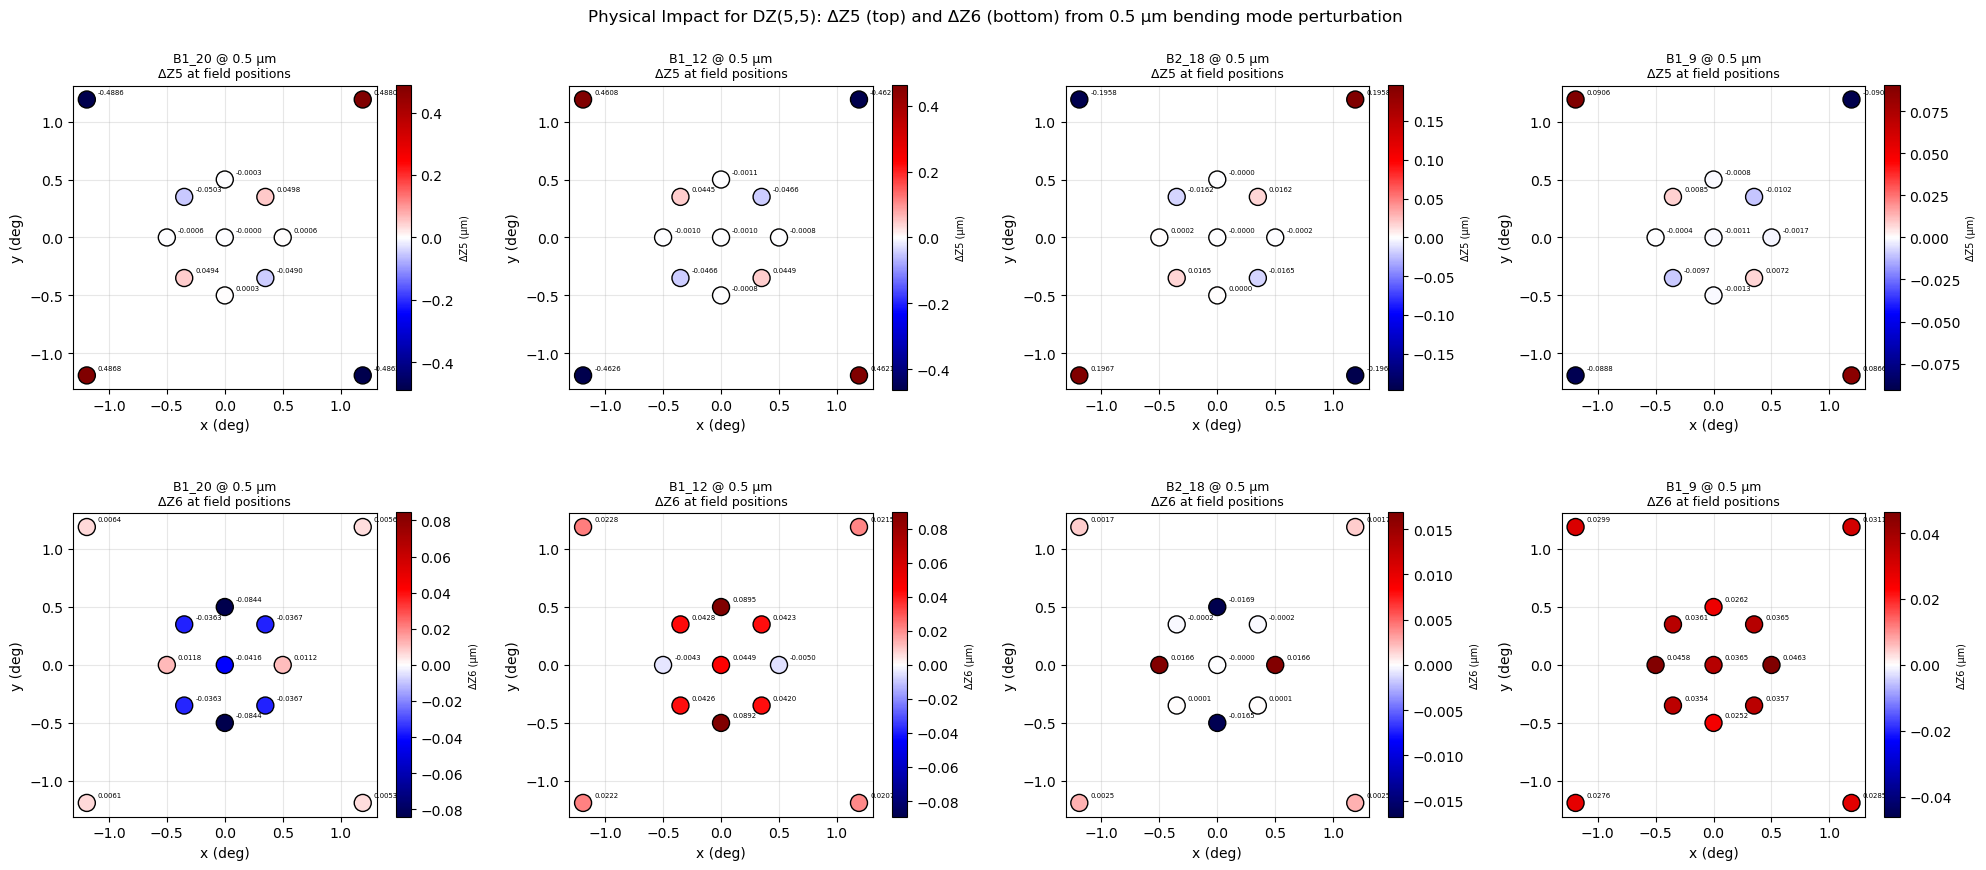

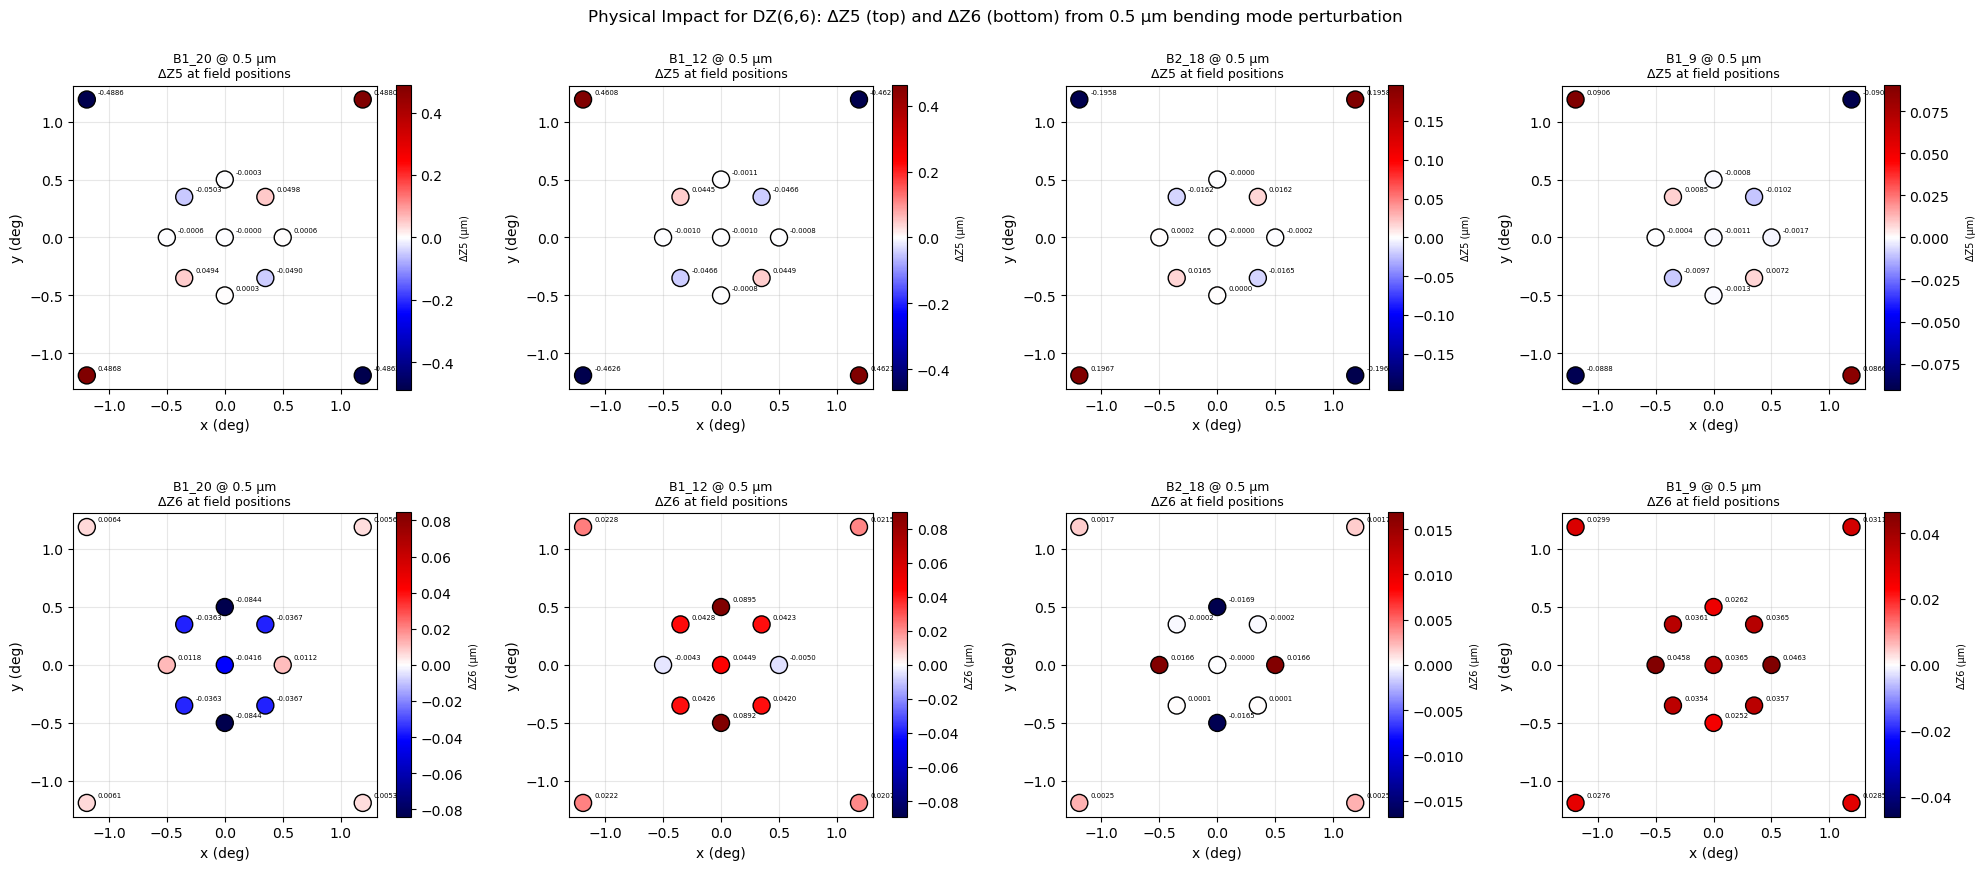

In [21]:
# Focal-plane plots: Z5 and Z6 wavefront change for top DOFs at 0.5 micron bending mode amplitude
# Focus on bending modes (DOF index >= 10) for the (5,5) and (6,6) target terms

for j_target, k_target in [(5, 5), (6, 6)]:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    
    # Select top bending-mode DOFs only
    bending_mask = np.arange(n_dof) >= 10
    coeffs_bending = np.where(bending_mask, coeffs, 0.0)
    order = np.argsort(np.abs(coeffs_bending))[::-1][:4]
    
    n_show_dof = len(order)
    fig, axes = plt.subplots(2, n_show_dof, figsize=(5 * n_show_dof, 9))
    
    for col_idx, d in enumerate(order):
        if np.abs(coeffs_bending[d]) < 1e-10:
            for row in range(2):
                axes[row, col_idx].set_visible(False)
            continue
        
        amp = 0.5  # microns for bending modes
        
        # Top row: Z5 change
        ax = axes[0, col_idx]
        dz5 = A_3d[:, p_z5, d] * amp
        vmax5 = max(np.max(np.abs(dz5)), 1e-10)
        scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=dz5, cmap='seismic',
                             vmin=-vmax5, vmax=vmax5, s=150, edgecolors='k', zorder=5)
        for i in range(n_fp):
            ax.annotate(f'{dz5[i]:.4f}', (fp_xy[i, 0], fp_xy[i, 1]),
                        textcoords='offset points', xytext=(8, 4), fontsize=5)
        ax.set_title(f'{labels_50dof[d]} @ {amp} \u03bcm\n\u0394Z5 at field positions', fontsize=9)
        ax.set_xlabel('x (deg)')
        ax.set_ylabel('y (deg)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
        cb.set_label('\u0394Z5 (\u03bcm)', fontsize=7)
        
        # Bottom row: Z6 change
        ax = axes[1, col_idx]
        dz6 = A_3d[:, p_z6, d] * amp
        vmax6 = max(np.max(np.abs(dz6)), 1e-10)
        scatter = ax.scatter(fp_xy[:, 0], fp_xy[:, 1], c=dz6, cmap='seismic',
                             vmin=-vmax6, vmax=vmax6, s=150, edgecolors='k', zorder=5)
        for i in range(n_fp):
            ax.annotate(f'{dz6[i]:.4f}', (fp_xy[i, 0], fp_xy[i, 1]),
                        textcoords='offset points', xytext=(8, 4), fontsize=5)
        ax.set_title(f'{labels_50dof[d]} @ {amp} \u03bcm\n\u0394Z6 at field positions', fontsize=9)
        ax.set_xlabel('x (deg)')
        ax.set_ylabel('y (deg)')
        ax.set_aspect('equal')
        ax.grid(alpha=0.3)
        cb = fig.colorbar(scatter, ax=ax, shrink=0.8)
        cb.set_label('\u0394Z6 (\u03bcm)', fontsize=7)
    
    fig.suptitle(f'Physical Impact for DZ({j_target},{k_target}): '
                 f'\u0394Z5 (top) and \u0394Z6 (bottom) from 0.5 \u03bcm bending mode perturbation',
                 fontsize=12)
    fig.tight_layout()
    plt.show()

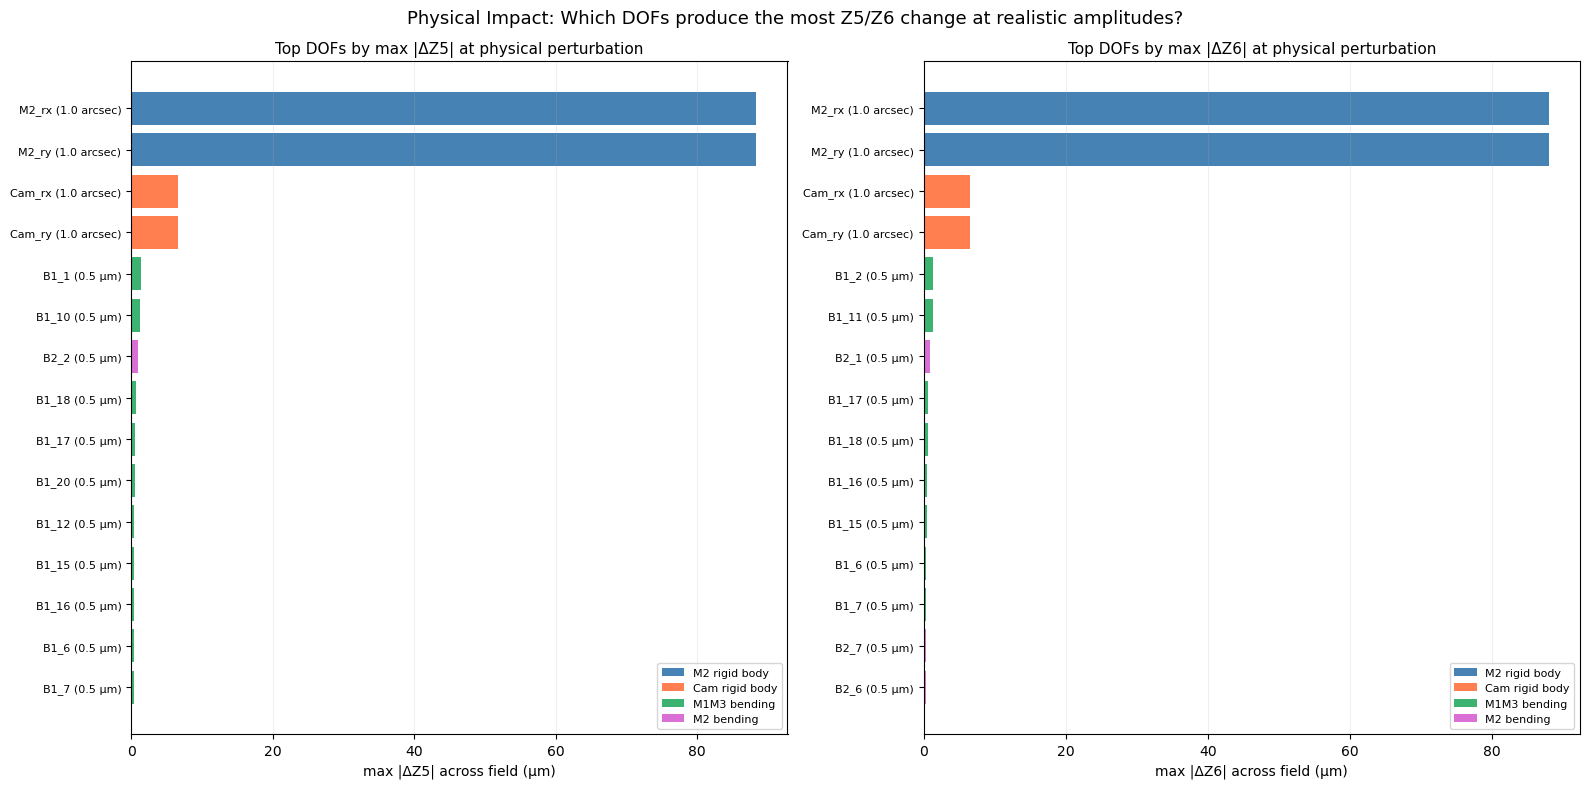

In [22]:
# Summary bar chart: max |delta Z5| and |delta Z6| across field for each DOF
# at physical perturbation amplitudes
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax_idx, (j_z, p_z, z_label) in enumerate([(5, p_z5, 'Z5'), (6, p_z6, 'Z6')]):
    ax = axes[ax_idx]
    
    # Compute max |delta Z_j| across all field positions for each DOF
    max_dz = np.zeros(n_dof)
    for d in range(n_dof):
        max_dz[d] = np.max(np.abs(A_3d[:, p_z, d])) * dof_perturbation[d]
    
    # Sort and show top 15
    order = np.argsort(max_dz)[::-1][:15]
    vals = max_dz[order]
    names = [f'{labels_50dof[d]} ({dof_perturbation[d]:.1f} {dof_units_50[d]})' for d in order]
    
    # Color by DOF type
    bar_colors = []
    for d in order:
        if d < 5:
            bar_colors.append('steelblue')   # M2 rigid body
        elif d < 10:
            bar_colors.append('coral')        # Cam rigid body
        elif d < 30:
            bar_colors.append('mediumseagreen')  # B1 bending
        else:
            bar_colors.append('orchid')       # B2 bending
    
    ax.barh(range(len(vals)), vals, color=bar_colors)
    ax.set_yticks(range(len(vals)), names, fontsize=8)
    ax.set_xlabel(f'max |\u0394{z_label}| across field (\u03bcm)')
    ax.set_title(f'Top DOFs by max |\u0394{z_label}| at physical perturbation', fontsize=11)
    ax.grid(alpha=0.2, axis='x')
    ax.invert_yaxis()
    
    # Legend for colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='steelblue', label='M2 rigid body'),
                       Patch(facecolor='coral', label='Cam rigid body'),
                       Patch(facecolor='mediumseagreen', label='M1M3 bending'),
                       Patch(facecolor='orchid', label='M2 bending')]
    ax.legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle('Physical Impact: Which DOFs produce the most Z5/Z6 change at realistic amplitudes?',
             fontsize=13)
fig.tight_layout()
plt.show()

<a id='summary'></a>
## 9. Summary

In [23]:
# Summary table
print('Summary: DOFs producing astigmatic field patterns')
print(f'  Using {n_fp} field positions ({n_wfs} WFS + {n_extra} extra)')
print(f'  Focal-plane Zernike basis: Z1-Z{k_fp_max} (rank {rank})')
print('=' * 95)
print(f'{"Target (j,k)":>15s} {"Best DOF":>12s} {"idx":>5s} {"coeff":>12s} '
      f'{"resid":>10s} {"2nd best":>12s} {"coeff":>12s}')
print('-' * 95)

for j_target, k_target in target_dz_terms:
    j_local = j_target - j_min
    k_local = k_target - 1
    coeffs = dz_coeff_all[:, j_local, k_local]
    order = np.argsort(np.abs(coeffs))[::-1]
    
    d1 = order[0]
    d2 = order[1]
    resid1 = dz_residual_all[d1, j_local]
    print(f'({j_target:2d},{k_target:2d})          '
          f'{labels_50dof[d1]:>12s} {d1:5d} {coeffs[d1]:12.6f} {resid1:10.2e} '
          f'{labels_50dof[d2]:>12s} {coeffs[d2]:12.6f}')

print('\nInterpretation:')
print('  (j=5, k=5): Astigmatism-45 in the pupil varying as astigmatism-45 across the field')
print('  (j=6, k=6): Astigmatism-0 in the pupil varying as astigmatism-0 across the field')
print('  (j=5, k=6): Astigmatism-45 in the pupil varying as astigmatism-0 across the field')
print('  (j=6, k=5): Astigmatism-0 in the pupil varying as astigmatism-45 across the field')
print('\nNote: residual indicates how well the Z1-Z6 basis captures the field variation.')
print('  Small residual = the field dependence is well-described by low-order Zernikes.')
print('  Large residual = significant higher-order field variation not captured by Z1-Z6.')

Summary: DOFs producing astigmatic field patterns
  Using 13 field positions (4 WFS + 9 extra)
  Focal-plane Zernike basis: Z1-Z6 (rank 6)
   Target (j,k)     Best DOF   idx        coeff      resid     2nd best        coeff
-----------------------------------------------------------------------------------------------
( 5, 5)                 B1_20    29     0.398485   2.98e-02        B1_12    -0.377643
( 6, 6)                 B1_20    29     0.443735   2.11e-03        B1_12    -0.435112
( 5, 6)                  B1_8    17     0.086350   3.18e-04         B2_9    -0.044670
( 6, 5)                  B1_8    17     0.077586   3.72e-03         B2_9    -0.040411

Interpretation:
  (j=5, k=5): Astigmatism-45 in the pupil varying as astigmatism-45 across the field
  (j=6, k=6): Astigmatism-0 in the pupil varying as astigmatism-0 across the field
  (j=5, k=6): Astigmatism-45 in the pupil varying as astigmatism-0 across the field
  (j=6, k=5): Astigmatism-0 in the pupil varying as astigmatism-45 